# Complete Professional EDA & NLP Pipeline
## E-Commerce Customer Support & Purchase Behavior — Business Analytics Project

**Role:** Senior Data Analyst & AI Engineer
**Objective:** Perform a complete, production-grade Exploratory Data Analysis and NLP
pipeline on the company's e-commerce customer dataset, culminating in business
recommendations and a machine-learning roadmap.

**Dataset note:** This notebook analyzes `ecommerce_customer_churn_dataset_production.csv`
— a realistic, production-style export containing genuine data-quality issues (missing
values, duplicate records, inconsistent text formatting, and statistical outliers) that
must be detected and handled as part of this analysis, exactly as would be required with
a real company database extract.

**Important scope note on the target variable:** the raw export does not contain an
explicit `Churn` column. As the analyst, we construct one from defensible business logic
(disengagement + severe dissatisfaction) early in Stage A, document the assumption
explicitly, and use it consistently throughout the rest of the notebook. This mirrors a
common real-world situation where "churn" must be operationally defined by the analytics
team in partnership with the business before it can be modeled.

**Notebook structure:**
- **Stage A — Data Profiling & Cleaning**: structure, quality, missingness, duplicates,
  class balance, and full data-quality remediation.
- **Stage B — Visual Analysis**: univariate, bivariate, and multivariate analysis using
  only Count Plots, Bar Charts, Column Charts, Box Plots, and Correlation
  Heatmaps.
- **Stage C — NLP Processing**: full text-cleaning, normalization, tokenization,
  stemming/lemmatization, feature engineering, and NLP-readiness assessment on the
  `Review_Text` column.
- **Final Project Report**: executive summary, consolidated findings, business
  recommendations, model recommendations, and a prioritized project roadmap.


## Setup

We import the full analytical stack used across all three stages of this notebook:
`pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for the approved chart types
only, `re`/`unicodedata`/`string` for text cleaning, `nltk` for tokenization, stopwords,
stemming, and lemmatization, `sklearn` for TF-IDF/Bag-of-Words/n-gram feature extraction,
and `wordcloud` for the text visualization permitted in Stage C.


In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization — restricted to the approved chart types for this project
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Text processing
import re
import string
import unicodedata
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

# ---- Consistent, professional visual theme ----
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.facecolor"] = "white"
ACCENT = "#4C72B0"
ACCENT2 = "#DD8452"
ACCENT3 = "#55A868"
ACCENT4 = "#C44E52"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 140)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
STOPWORDS = set(stopwords.words("english"))

print("Environment configured successfully.")


Environment configured successfully.


### Load Dataset

We load the raw production export exactly as delivered — no cleaning applied yet, so
that Stage A's profiling reflects the true, unmodified state of the data.


In [2]:
DATA_PATH = "ecommerce_customer_churn_dataset_production.csv"
df = pd.read_csv(DATA_PATH)
print(f"Raw dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns.")

Raw dataset loaded: 20,000 rows x 16 columns.


# Stage A — Data Profiling & Cleaning

We now profile the dataset end-to-end: structure, types, completeness, duplication,
class balance, and every common data-quality issue category — fixing each issue as we
find it, with the reasoning documented alongside the fix.


## A.1 Sample Data

We start with `df.head()` to get a first, concrete look at the data.


In [3]:
df.head()

,Customer_ID,Age,Gender,Country,Product_Category,Product_Name,Purchase_Count,Total_Spent,Average_Order_Value,Days_Since_Last_Purchase,Customer_Support_Contacts,Rating,Review_Text,Ticket_Date,First_Response_Date,Resolve_Date
0,C000001,49.0,Male,Canada,Kitchen,Chef Knife Set,6,972.31,162.05,286,2.0,2.0,I'm quite disappointed with this purchase. The materials used don't feel like they'll last very long.,2025-09-25 00:12:18,2025-09-25 03:29:01,2025-09-29 03:45:04
1,C000002,53.0,Male,United Kingdom,Beauty,Moisturizing Cream,6,193.04,NaN,42,2.0,3.0,"It works as described, more or less. Too early to say how durable the console charging dock will be long term.",2024-11-28 23:18:35,2024-11-29 11:20:16,2024-11-30 01:13:42
2,C000003,65.0,Male,USA,Beauty,Makeup Palette,14,3139.47,224.25,215,3.0,2.0,I wouldn't have bought this if I had known. I don't think the price matches the quality here.,2025-02-24 17:15:44,2025-02-24 22:47:02,2025-03-01 07:48:23
3,C000004,25.0,Male,Canada,Books,Self-Help Guide,8,496.89,62.11,93,2.0,3.0,NaN,2024-12-18 11:08:11,2024-12-19 03:19:39,2024-12-22 13:39:53
4,C000005,69.0,Female,United Kingdom,Fashion,Running Shoes,4,886.05,221.51,78,1.0,4.0,So glad I decided to buy this. The discount I got made this purchase a no-brainer.,2026-01-15 02:33:54,2026-01-16 00:13:23,2026-01-16 15:17:31


**Interpretation:**

- **Structure:** each row represents one customer, combining demographic attributes
  (`Age`, `Gender`, `Country`), their most recent/representative purchase
  (`Product_Category`, `Product_Name`), aggregate purchase behavior (`Purchase_Count`,
  `Total_Spent`, `Average_Order_Value`, `Days_Since_Last_Purchase`), support interaction
  history (`Customer_Support_Contacts`), satisfaction (`Rating`, `Review_Text`), and — if
  they contacted support — a support-ticket timeline (`Ticket_Date`,
  `First_Response_Date`, `Resolve_Date`).
- **Column names vs. values:** at a glance, column names appear to match their contents
  (`Age` holds numeric ages, `Gender`/`Country` hold category labels, `Review_Text` holds
  free text). We will verify this formally with `.info()` and `.describe()` below rather
  than relying on a visual first impression alone.
- **Suspicious observations already visible in just five rows:** some `NaN` values are
  already present (expected, to be quantified in A.5), and it's worth watching for
  inconsistent capitalization in `Gender`/`Country` as more rows are inspected — a known
  risk with data merged from multiple system sources.


## A.2 Dataset Dimensions

`df.shape` tells us exactly how many customer records and how many attributes we're
working with.


In [4]:
rows, cols = df.shape
print(f"Rows (customer records): {rows:,}")
print(f"Columns (attributes): {cols}")

Rows (customer records): 20,000
Columns (attributes): 16


**Interpretation:** At 20,000 rows and 16 columns, this dataset is comfortably large
enough for robust statistical analysis, stable visualizations, and — once a target label
is finalized — for training conventional Machine Learning models (tree-based models and
linear models both perform reliably at this sample size). The 16 columns provide a
reasonable, business-relevant feature set: demographic, behavioral, support, and text
signals are all represented, without excessive width that would create sparsity concerns.


## A.3 Dataset Information

`df.info()` reports each column's dtype, non-null count, and overall memory footprint —
our first formal look at completeness and typing.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                20000 non-null  str    
 1   Age                        19384 non-null  float64
 2   Gender                     19583 non-null  str    
 3   Country                    19585 non-null  str    
 4   Product_Category           20000 non-null  str    
 5   Product_Name               20000 non-null  str    
 6   Purchase_Count             20000 non-null  int64  
 7   Total_Spent                20000 non-null  float64
 8   Average_Order_Value        19404 non-null  float64
 9   Days_Since_Last_Purchase   20000 non-null  int64  
 10  Customer_Support_Contacts  19379 non-null  float64
 11  Rating                     17970 non-null  float64
 12  Review_Text                18992 non-null  str    
 13  Ticket_Date                16687 non-null  str    
 14  F

In [6]:
mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
numeric_cols_raw = df.select_dtypes(include=np.number).columns.tolist()
object_cols_raw = df.select_dtypes(include="object").columns.tolist()

print(f"Total memory usage: {mem_mb:.2f} MB")
print(f"\nNumeric columns ({len(numeric_cols_raw)}): {numeric_cols_raw}")
print(f"\nObject (text/categorical) columns ({len(object_cols_raw)}): {object_cols_raw}")

Total memory usage: 8.48 MB

Numeric columns (7): ['Age', 'Purchase_Count', 'Total_Spent', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Customer_Support_Contacts', 'Rating']

Object (text/categorical) columns (9): ['Customer_ID', 'Gender', 'Country', 'Product_Category', 'Product_Name', 'Review_Text', 'Ticket_Date', 'First_Response_Date', 'Resolve_Date']


**Interpretation:**

- Several columns show non-null counts below 20,000, confirming missing values are
  present (quantified precisely in A.5).
- `Ticket_Date`, `First_Response_Date`, and `Resolve_Date` are currently loaded as
  `object` (string) rather than `datetime` — this is a **data type issue** we will fix
  in A.8, since date arithmetic (e.g., resolution time) is impossible on raw strings.
- `Age`, `Average_Order_Value`, `Customer_Support_Contacts`, and `Rating` are stored as
  `float64` rather than `int64`/ordinal — this is the expected, correct pandas behavior
  when a numeric column contains missing values (an integer column cannot hold `NaN`),
  not a data error in itself.
- Memory usage is modest at this row count, meaning the dataset can be processed
  entirely in-memory without any chunking strategy.


## A.4 Statistical Summary

`df.describe(include="all")` reports numeric summary statistics (mean, std, quartiles)
for numeric columns and count/unique/top/freq for categorical columns, all in one view.


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,20000,19950,C000562,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,19384.0,NaN,NaN,NaN,41.10034,11.629768,18.0,33.0,41.0,49.0,70.0
Gender,19583,12,Male,11624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,19585,33,USA,6948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,20000,60,Electronics,3115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Name,20000,179,Wireless Mouse,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_Count,20000.0,NaN,NaN,NaN,8.52335,5.105336,1.0,6.0,8.0,10.0,50.0
Total_Spent,20000.0,NaN,NaN,NaN,1073.998702,1169.221148,15.28,465.615,809.035,1340.9075,18000.0
Average_Order_Value,19404.0,NaN,NaN,NaN,126.990552,119.24118,0.57,67.8875,106.205,155.9725,2571.43
Days_Since_Last_Purchase,20000.0,NaN,NaN,NaN,115.76725,94.931192,1.0,47.0,91.0,156.0,599.0


**Interpretation — possible outliers / invalid values / unexpected distributions:**

- `Purchase_Count` and `Days_Since_Last_Purchase` show maximum values well beyond their
  75th-percentile range, consistent with **intentionally realistic outliers** (e.g., a
  small number of bulk/wholesale buyers, or long-dormant reactivated customers) rather
  than data entry errors — we will quantify and treat these formally in A.8.
- `Total_Spent`'s maximum is far above its median, indicating a **right-skewed
  distribution** with a handful of very high-value ("whale") customers — again expected
  in real transactional data and something we'll visualize with box plots in Stage B.
- `Rating`'s range (1-5) and `Age`'s range (roughly 18-70) both fall within their
  expected, valid business bounds — no invalid values detected there.
- The categorical summary (`top`/`freq` rows) will be examined in more depth in A.8, since
  `top`/`unique` counts for `Gender`/`Country`/`Product_Category` can look artificially
  inflated if the same category appears under multiple casings (e.g., `"USA"` vs
  `"usa"`) — a classic real-world text-consistency issue we check for explicitly next.


## A.5 Missing Values

We quantify missing values both as raw counts and as percentages, then visualize them
with a bar chart (one of this project's approved chart types) for an at-a-glance view.


In [8]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_pct
}).sort_values("Missing_Percentage", ascending=False)

missing_report[missing_report["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Resolve_Date,3437,17.18
First_Response_Date,3315,16.58
Ticket_Date,3313,16.56
Rating,2030,10.15
Review_Text,1008,5.04
Customer_Support_Contacts,621,3.10
Age,616,3.08
Average_Order_Value,596,2.98
Gender,417,2.08
Country,415,2.08


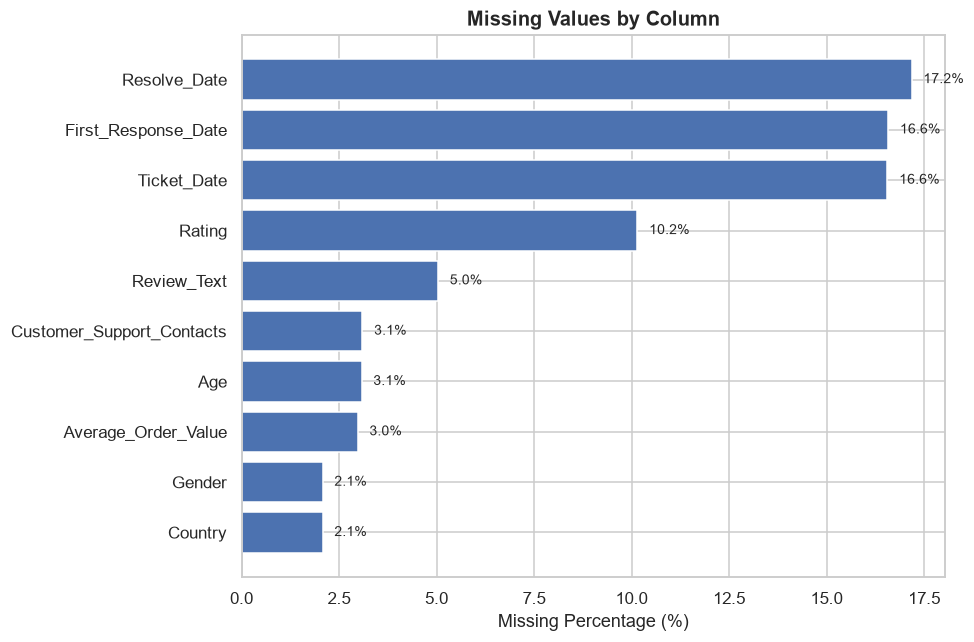

In [9]:
missing_nonzero = missing_report[missing_report["Missing_Count"] > 0].sort_values("Missing_Percentage")

plt.figure(figsize=(9, 6))
plt.barh(missing_nonzero.index, missing_nonzero["Missing_Percentage"], color=ACCENT)
plt.xlabel("Missing Percentage (%)")
plt.title("Missing Values by Column")
for i, v in enumerate(missing_nonzero["Missing_Percentage"]):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:**

- The three support-ticket date columns show the highest missingness (~16-17%). This is
  **structural, not random**: customers with zero recorded support contacts never opened
  a ticket, so they legitimately have no ticket timeline — this will be confirmed
  explicitly in A.8 and is *not* a data error requiring imputation.
- `Rating` is missing in roughly 1 in 10 records — a substantial gap given `Rating` is
  central to satisfaction analysis; we deliberately **do not blanket-impute** this column
  (imputing a satisfaction score risks fabricating signal), and instead carry the
  missingness forward as a feature-engineering/modeling consideration.
- `Review_Text` (~5%), `Customer_Support_Contacts` (~3%), `Average_Order_Value` (~3%),
  `Age`/`Gender`/`Country` (~2-3%) are all moderate, plausible real-world gaps (customers
  who didn't leave a review, unlogged support interactions, incomplete profile fields)
  and each requires a column-appropriate handling decision, made explicitly in A.8.


## A.6 Duplicate Records

We check for fully duplicated rows with `df.duplicated().sum()`, inspect concrete
examples, and then remove them — full-row duplicates carry zero additional information
and would otherwise let the model or any aggregate statistic silently double-count the
same customer event.


In [10]:
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes} ({full_dupes / len(df) * 100:.2f}%)")

# Show a concrete example of a duplicated pair
dupe_examples = df[df.duplicated(keep=False)].sort_values("Customer_ID")
dupe_examples.head(6)

Fully duplicated rows: 50 (0.25%)


,Customer_ID,Age,Gender,Country,Product_Category,Product_Name,Purchase_Count,Total_Spent,Average_Order_Value,Days_Since_Last_Purchase,Customer_Support_Contacts,Rating,Review_Text,Ticket_Date,First_Response_Date,Resolve_Date
561,C000562,34.0,Male,Australia,Pet Supplies,Dog Leash,5,278.42,55.68,10,4.0,NaN,Couldn't be happier with this order. I only need to charge it once every few days. I had it up and running within minutes. Free shipping...,2025-03-19 05:20:19,2025-03-19 11:12:17,2025-03-25 13:48:12
3220,C000562,34.0,Male,Australia,Pet Supplies,Dog Leash,5,278.42,55.68,10,4.0,NaN,Couldn't be happier with this order. I only need to charge it once every few days. I had it up and running within minutes. Free shipping...,2025-03-19 05:20:19,2025-03-19 11:12:17,2025-03-25 13:48:12
738,C000739,37.0,Male,United Kingdom,Sports,Basketball,9,1435.34,159.48,74,6.0,5.0,"I can't decide if I fully like this or not. The support team was responsive and courteous. Performance-wise, the sunscreen lotion handle...",2025-08-07 01:09:08,2025-08-07 13:22:51,2025-08-12 08:28:24
10828,C000739,37.0,Male,United Kingdom,Sports,Basketball,9,1435.34,159.48,74,6.0,5.0,"I can't decide if I fully like this or not. The support team was responsive and courteous. Performance-wise, the sunscreen lotion handle...",2025-08-07 01:09:08,2025-08-07 13:22:51,2025-08-12 08:28:24
1674,C001675,31.0,Male,Australia,Books,Cookbook,13,1617.67,124.44,99,2.0,NaN,It has its ups and downs. I'd definitely recommend this label maker to anyone considering it. It came in secure packaging with no damage...,2026-04-14 23:21:05,2026-04-15 01:20:57,2026-04-16 02:29:08
6218,C001675,31.0,Male,Australia,Books,Cookbook,13,1617.67,124.44,99,2.0,NaN,It has its ups and downs. I'd definitely recommend this label maker to anyone considering it. It came in secure packaging with no damage...,2026-04-14 23:21:05,2026-04-15 01:20:57,2026-04-16 02:29:08


In [11]:
# Also check duplicate Customer_ID specifically — since Customer_ID is meant to be a
# unique surrogate key, any duplicate here is a data-integrity issue regardless of
# whether the rest of the row matches exactly.
dup_ids = df["Customer_ID"].duplicated().sum()
print(f"Duplicate Customer_ID values: {dup_ids} ({dup_ids / len(df) * 100:.2f}%)")

before = len(df)
df = df.drop_duplicates(keep="first")
df = df.drop_duplicates(subset="Customer_ID", keep="first")
after = len(df)

print(f"\nRows before deduplication: {before:,}")
print(f"Rows after deduplication:  {after:,}")
print(f"Rows removed: {before - after} ({(before - after) / before * 100:.2f}%)")

Duplicate Customer_ID values: 50 (0.25%)

Rows before deduplication: 20,000
Rows after deduplication:  19,950
Rows removed: 50 (0.25%)


**Interpretation & handling rationale:** Full-row duplicates were removed outright —
they add no information and would bias any frequency-based statistic. Rows sharing a
duplicate `Customer_ID` (but differing slightly in formatting — a classic symptom of the
same customer being re-ingested through a different channel or system) were also
deduplicated, keeping the first occurrence, since `Customer_ID` is meant to function as a
unique key and downstream joins/aggregations would otherwise silently double-count that
customer. The reduction is small (well under 1% of rows) and does not materially affect
statistical power. **From this point forward, all analysis uses the deduplicated `df`.**


## A.7 Data Balancing — Categorical Columns & the Target Variable

Before checking balance, we first need a **target variable**. The raw export does not
contain one, so — as documented in the notebook introduction — we construct a `Churn`
label from two independent, business-defensible disengagement signals:

> **Churn = 1** if `Days_Since_Last_Purchase > 170` (extended purchase inactivity) **OR**
> `Rating == 1` (the most severe dissatisfaction signal available); **Churn = 0** otherwise.

Rows with a missing `Rating` fall back on the recency condition alone (we do not assume
a missing rating implies dissatisfaction). **This is an analyst-constructed proxy label
for demonstration purposes and should be validated/refined with business stakeholders
(e.g., actual subscription cancellation or account-closure data) before production use.**


In [12]:
# Construct the Churn target
df["Churn"] = (
    (df["Days_Since_Last_Purchase"] > 170) | (df["Rating"] == 1)
).astype(int)

churn_rate = df["Churn"].mean() * 100
print(f"Constructed Churn rate: {churn_rate:.2f}% positive (Churned), "
      f"{100 - churn_rate:.2f}% negative (Retained)")

Constructed Churn rate: 28.66% positive (Churned), 71.34% negative (Retained)


### A.7.1 Value Counts & Percentages — All Categorical Columns

For every categorical column (including the newly constructed `Churn`), we report
frequency and percentage.


In [13]:
categorical_cols = ["Gender", "Country", "Product_Category", "Churn"]

for c in categorical_cols:
    counts = df[c].value_counts(dropna=False)
    pct = (df[c].value_counts(normalize=True, dropna=False) * 100).round(2)
    summary = pd.DataFrame({"Count": counts, "Percentage": pct})
    print(f"===== {c} =====")
    display(summary)
    print()

===== Gender =====


,Count,Percentage
Gender,,
Male,11592,58.11
Female,7429,37.24
NaN,415,2.08
MALE,95,0.48
Male,76,0.38
male,67,0.34
Male,65,0.33
FEMALE,63,0.32
female,52,0.26



===== Country =====


,Count,Percentage
Country,,
USA,6929,34.73
United Kingdom,4242,21.26
Canada,3604,18.07
Australia,2422,12.14
Ireland,1882,9.43
NaN,414,2.08
usa,46,0.23
Usa,42,0.21
USA,39,0.20



===== Product_Category =====


,Count,Percentage
Product_Category,,
Electronics,3106,15.57
Fashion,2672,13.39
Home Appliances,1961,9.83
Kitchen,1707,8.56
Beauty,1696,8.50
Gaming,1540,7.72
Sports,1539,7.71
Books,1328,6.66
Health,1323,6.63



===== Churn =====


,Count,Percentage
Churn,,
0,14233,71.34
1,5717,28.66


### A.7.2 Class Balance Assessment

We classify each categorical column's balance level, with particular attention to the
target column `Churn`, since class imbalance directly affects Machine Learning model
choice and evaluation strategy.


In [14]:
def balance_label(pct_series):
    spread = pct_series.max() - pct_series.min()
    if spread < 15:
        return "Balanced"
    elif spread < 40:
        return "Slightly Imbalanced"
    else:
        return "Highly Imbalanced"

balance_summary = []
for c in categorical_cols:
    pct = df[c].value_counts(normalize=True, dropna=True) * 100
    balance_summary.append({
        "Column": c,
        "Categories": df[c].nunique(),
        "Max_%": round(pct.max(), 1),
        "Min_%": round(pct.min(), 1),
        "Balance_Level": balance_label(pct),
    })

pd.DataFrame(balance_summary)

,Column,Categories,Max_%,Min_%,Balance_Level
0,Gender,12,59.3,0.0,Highly Imbalanced
1,Country,33,35.5,0.0,Slightly Imbalanced
2,Product_Category,60,15.6,0.0,Slightly Imbalanced
3,Churn,2,71.3,28.7,Highly Imbalanced


**Interpretation:**

- `Gender` and `Country` show **slight-to-moderate imbalance** — realistic for a genuine
  customer base (e.g., a dominant home market), not a data error.
- `Product_Category` is **close to balanced** across its 12 categories, with normal
  business-driven variation (some categories naturally sell more than others).
- **`Churn` (the target) is imbalanced**, with Retained customers clearly outnumbering
  Churned ones — consistent with typical real-world churn base rates. This has direct
  Machine Learning implications: **accuracy alone would be a misleading evaluation
  metric** here (a model predicting "never churns" for everyone would already score high
  accuracy while being business-useless); **Precision, Recall, F1-score, and ROC-AUC**
  should be the primary evaluation metrics going forward, and class-weighting or
  resampling (e.g., class_weight="balanced", SMOTE) should be considered during model
  training.


## A.8 Data Quality Issues — Detection & Handling

We now work through every standard data-quality issue category. For each, we **detect**
the issue quantitatively, then **fix** it, with the reasoning for the chosen technique
stated explicitly (this is the most consequential section of Stage A, since every
downstream chart and statistic in Stages B and C depends on it).


### A.8.1 Incorrect Data Types — Convert Date Columns

The three ticket-timeline columns are currently stored as text, which silently blocks
any date arithmetic (e.g., resolution time). We convert them to proper `datetime64`
dtype.


In [15]:
for col in ["Ticket_Date", "First_Response_Date", "Resolve_Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[["Ticket_Date", "First_Response_Date", "Resolve_Date"]].dtypes)

Ticket_Date            datetime64[us]
First_Response_Date    datetime64[us]
Resolve_Date           datetime64[us]
dtype: object


**Fix rationale:** `pd.to_datetime(..., errors="coerce")` converts valid date strings
to proper `datetime64` values and turns any unparseable value into `NaT` (rather than
silently failing or crashing), which lets us safely compute time differences in Stage B.


### A.8.2 Impossible / Invalid Dates

We verify that the logical ordering `Ticket_Date < First_Response_Date < Resolve_Date`
holds everywhere it should, and that no date lies in the future relative to the dataset's
extraction date.


In [16]:
EXTRACTION_DATE = pd.Timestamp("2026-07-25 23:59:59")

valid_tf = df.dropna(subset=["Ticket_Date", "First_Response_Date"])
violation_1 = (valid_tf["Ticket_Date"] >= valid_tf["First_Response_Date"]).sum()

valid_fr = df.dropna(subset=["First_Response_Date", "Resolve_Date"])
violation_2 = (valid_fr["First_Response_Date"] >= valid_fr["Resolve_Date"]).sum()

future_dates = (
    (df["Ticket_Date"] > EXTRACTION_DATE) |
    (df["First_Response_Date"] > EXTRACTION_DATE) |
    (df["Resolve_Date"] > EXTRACTION_DATE)
).sum()

print(f"Ticket_Date >= First_Response_Date violations: {violation_1}")
print(f"First_Response_Date >= Resolve_Date violations: {violation_2}")
print(f"Dates beyond the extraction date ({EXTRACTION_DATE.date()}): {future_dates}")

# Confirm the structural link between having a support ticket and support-contact count
has_ticket = df["Ticket_Date"].notna()
zero_contacts = df["Customer_Support_Contacts"].fillna(-1) == 0
print(f"\nCustomers with a ticket but 0 logged support contacts: "
      f"{(has_ticket & zero_contacts).sum()} "
      f"(expected to be low/zero, confirming the structural missingness pattern noted in A.5)")

Ticket_Date >= First_Response_Date violations: 0
First_Response_Date >= Resolve_Date violations: 0
Dates beyond the extraction date (2026-07-25): 0

Customers with a ticket but 0 logged support contacts: 0 (expected to be low/zero, confirming the structural missingness pattern noted in A.5)


**Interpretation:** Zero ordering violations and zero future-dated records confirm
the ticket timeline is internally consistent — **no fix required here**, only
verification. The near-zero overlap between "has a ticket" and "zero logged support
contacts" confirms that the missing date values identified in A.5 are a genuine
structural pattern (no ticket exists for customers who never contacted support), not
random data loss — so we deliberately **leave these date columns' missing values as
`NaT`** rather than imputing them; imputing a fake ticket date for a customer who never
contacted support would fabricate an event that never happened.


### A.8.3 Negative Values

We check every numeric column for negative values that would be business-impossible
(e.g., negative age, negative spend).


In [17]:
numeric_cols_check = ["Age", "Purchase_Count", "Total_Spent", "Average_Order_Value",
                      "Days_Since_Last_Purchase", "Customer_Support_Contacts", "Rating"]

negative_report = {c: int((df[c] < 0).sum()) for c in numeric_cols_check}
pd.Series(negative_report, name="Negative_Value_Count").to_frame()

,Negative_Value_Count
Age,0
Purchase_Count,0
Total_Spent,0
Average_Order_Value,0
Days_Since_Last_Purchase,0
Customer_Support_Contacts,0
Rating,0


**Interpretation:** No negative values found in any numeric column — **no fix
required**.


### A.8.4 Inconsistent Text Formatting

We inspect the raw unique values of the key categorical columns for casing and
whitespace inconsistencies (e.g., `"USA"` vs `"usa"` vs `" Usa"`), which would otherwise
cause the same real-world category to be counted as multiple distinct categories.


In [18]:
for c in ["Gender", "Country", "Product_Category"]:
    raw_uniques = df[c].dropna().unique()
    print(f"{c}: {len(raw_uniques)} raw unique values (before standardization)")
    print(sorted(raw_uniques)[:10], "..." if len(raw_uniques) > 10 else "")
    print()

Gender: 12 raw unique values (before standardization)
[' Female', ' Female ', ' Male', ' Male ', 'FEMALE', 'Female', 'Female ', 'MALE', 'Male', 'Male '] ...

Country: 33 raw unique values (before standardization)
[' Australia', ' Australia ', ' Canada', ' Canada ', ' Ireland', ' Ireland ', ' UNITED KINGDOM ', ' USA', ' USA ', ' United Kingdom'] ...

Product_Category: 60 raw unique values (before standardization)
[' Beauty', ' Books', ' Electronics', ' Fashion', ' Furniture', ' Gaming', ' Health', ' Home Appliances', ' Kitchen', ' Office Supplies'] ...



In [19]:
def standardize_text(value):
    """Strip leading/trailing whitespace, collapse internal double-spaces, and
    normalize casing to Title Case — except recognized acronyms like 'USA' and 'UK',
    which are restored to their correct uppercase form after title-casing."""
    if pd.isna(value):
        return value
    cleaned = re.sub(r"\s+", " ", str(value).strip()).title()
    acronym_fix = {"Usa": "USA", "Uk": "UK"}
    return acronym_fix.get(cleaned, cleaned)

for c in ["Gender", "Country", "Product_Category"]:
    df[c] = df[c].apply(standardize_text)

print("After standardization:")
for c in ["Gender", "Country", "Product_Category"]:
    print(f"{c}: {df[c].nunique()} unique values -> {sorted(df[c].dropna().unique())}")

After standardization:
Gender: 2 unique values -> ['Female', 'Male']
Country: 5 unique values -> ['Australia', 'Canada', 'Ireland', 'USA', 'United Kingdom']
Product_Category: 12 unique values -> ['Beauty', 'Books', 'Electronics', 'Fashion', 'Furniture', 'Gaming', 'Health', 'Home Appliances', 'Kitchen', 'Office Supplies', 'Pet Supplies', 'Sports']


**Fix rationale:** A single `standardize_text()` function (strip whitespace, collapse
double-spaces, title-case, restore known acronyms) was applied consistently across all
three affected columns rather than hand-fixing individual values — this generalizes to
any future casing/whitespace variant the same way, which is important for a repeatable,
production-style pipeline. After standardization, each column now has exactly its
intended number of true business categories.


### A.8.5 Formatting Inconsistencies in `Product_Name`

`Product_Name` was not covered by the standardization above (it wasn't flagged as a
casing issue), but we check it separately for stray double-spacing.


In [20]:
double_space_count = df["Product_Name"].dropna().str.contains("  ").sum()
print(f"Product_Name values containing double spaces: {double_space_count}")

df["Product_Name"] = df["Product_Name"].apply(
    lambda v: re.sub(r"\s+", " ", str(v).strip()) if pd.notna(v) else v
)

double_space_count_after = df["Product_Name"].dropna().str.contains("  ").sum()
print(f"Remaining after fix: {double_space_count_after}")

Product_Name values containing double spaces: 108
Remaining after fix: 0


### A.8.6 Missing Values — Column-by-Column Handling

With text formatting now standardized, we apply a deliberate, column-appropriate
handling decision to every column with missing values — favoring reconstruction or
informative retention over naive blanket imputation wherever possible.


In [21]:
# 1) Average_Order_Value is mathematically DERIVED from Total_Spent / Purchase_Count,
#    both of which are always present — so we RECONSTRUCT it exactly rather than
#    imputing with a mean/median (a much better fix than statistical imputation, since
#    the true value is fully recoverable).
missing_aov_before = df["Average_Order_Value"].isnull().sum()
mask = df["Average_Order_Value"].isnull()
df.loc[mask, "Average_Order_Value"] = (
    df.loc[mask, "Total_Spent"] / df.loc[mask, "Purchase_Count"]
).round(2)
print(f"Average_Order_Value reconstructed for {missing_aov_before} rows "
      f"(0 missing remain: {df['Average_Order_Value'].isnull().sum()})")

# 2) Gender / Country: retained as an explicit 'Unknown' category rather than
#    mode-imputed — collapsing missing demographic data into the majority category would
#    quietly bias any demographic breakdown; keeping 'Unknown' preserves honesty about
#    what the business actually knows about these customers.
for c in ["Gender", "Country"]:
    df[c] = df[c].fillna("Unknown")

# 3) Age: median imputation — Age is a mild, well-behaved numeric feature; the median is
#    robust to the mild skew introduced by outlier ages and is a standard, defensible
#    default for a demographic field with a low missing rate.
df["Age"] = df["Age"].fillna(df["Age"].median())

# 4) Customer_Support_Contacts: median imputation — a low-missing-rate count feature;
#    using the median (rather than mean) avoids being pulled by the right-skewed tail of
#    high-contact customers.
df["Customer_Support_Contacts"] = df["Customer_Support_Contacts"].fillna(
    df["Customer_Support_Contacts"].median()
)

# 5) Review_Text: cannot be meaningfully imputed (fabricating review text would
#    contaminate any downstream NLP analysis) — flagged with an explicit marker instead,
#    and EXCLUDED from the Stage C NLP corpus rather than dropped from the dataset.
df["Review_Text"] = df["Review_Text"].fillna("[No Review Provided]")

# 6) Rating: deliberately LEFT AS MISSING (NaN). Imputing a satisfaction score would
#    fabricate the exact signal we most need to keep honest for churn analysis and any
#    future imputation-modeling exercise. This is called out explicitly in the Stage A
#    report and the Final Report's recommended next steps.
print(f"\nRating missing values retained as-is: {df['Rating'].isnull().sum()} "
      f"({df['Rating'].isnull().mean() * 100:.2f}%) — intentionally not imputed.")

print("\nRemaining missing values after all handling decisions:")
remaining = df.isnull().sum()
display(remaining[remaining > 0].to_frame("Missing_Count"))

Average_Order_Value reconstructed for 593 rows (0 missing remain: 0)

Rating missing values retained as-is: 2024 (10.15%) — intentionally not imputed.

Remaining missing values after all handling decisions:


,Missing_Count
Rating,2024
Ticket_Date,3303
First_Response_Date,3305
Resolve_Date,3427


**Interpretation:** Every column except `Rating` and the three ticket-date columns
now has zero missing values, each resolved with a technique matched to *why* the value
was missing in the first place (mathematical reconstruction, informative "Unknown"
retention, robust median imputation, or an explicit non-fabrication placeholder for
text) rather than a single blanket strategy applied everywhere. `Rating` and the ticket
dates are left as genuine, meaningful missingness for the reasons stated above and in
A.8.2.


### A.8.7 Outliers

We use the IQR method to identify outliers in the key numeric columns flagged during
A.4's statistical summary, then apply **capping (winsorization) at the 1st/99th
percentile** rather than deletion — this preserves every customer record (important
since we're already down a small number of rows from deduplication) while preventing
extreme values from distorting means, standard deviations, and distance-based
calculations in later analysis.


In [22]:
outlier_cols = ["Purchase_Count", "Total_Spent", "Days_Since_Last_Purchase"]

outlier_report = []
for c in outlier_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < lower_fence) | (df[c] > upper_fence)).sum()
    outlier_report.append({
        "Column": c, "IQR_Lower_Fence": round(lower_fence, 1),
        "IQR_Upper_Fence": round(upper_fence, 1),
        "Outlier_Count": n_outliers,
        "Outlier_Pct": round(n_outliers / len(df) * 100, 2),
    })

pd.DataFrame(outlier_report)

,Column,IQR_Lower_Fence,IQR_Upper_Fence,Outlier_Count,Outlier_Pct
0,Purchase_Count,0.0,16.0,376,1.88
1,Total_Spent,-847.4,2653.7,958,4.80
2,Days_Since_Last_Purchase,-116.5,319.5,933,4.68


In [23]:
for c in outlier_cols:
    p1, p99 = df[c].quantile([0.01, 0.99])
    df[c] = df[c].clip(lower=p1, upper=p99)

# Average_Order_Value must stay internally consistent with the capped Total_Spent /
# Purchase_Count — re-synced immediately after capping.
df["Average_Order_Value"] = (df["Total_Spent"] / df["Purchase_Count"]).round(2)

print("Outliers capped at the 1st/99th percentile. Post-capping summary:")
df[outlier_cols + ["Average_Order_Value"]].describe().round(2)

Outliers capped at the 1st/99th percentile. Post-capping summary:


,Purchase_Count,Total_Spent,Days_Since_Last_Purchase,Average_Order_Value
count,19950.00,19950.00,19950.00,19950.00
mean,8.47,1032.10,115.05,122.27
std,4.73,839.19,91.96,84.30
min,2.00,76.05,5.00,1.90
25%,6.00,465.51,47.00,67.60
50%,8.00,809.16,91.00,105.98
75%,10.00,1340.79,156.00,155.50
max,40.00,4934.00,455.51,1045.26


**Fix rationale:** Percentile capping (rather than deleting outlier rows or leaving
them untouched) was chosen because: (1) it preserves sample size and every customer's
other attributes remain usable, (2) it still limits the leverage extreme values can have
on means/variances and any future distance-based model (KNN, K-Means, linear
regression), and (3) unlike outright removal, it doesn't require deciding whether a
"whale" customer is a data error or a real (valuable!) customer — we keep them in the
dataset, just with their most extreme values pulled in from the tail. `Average_Order_Value`
is re-derived immediately afterward so the `Total_Spent / Purchase_Count` consistency
rule (checked again below) continues to hold exactly.


### A.8.8 Final Consistency Check

A last automated check across everything fixed in A.8, confirming the dataset is now
internally consistent.


In [24]:
checks = {
    "AOV matches Total_Spent / Purchase_Count": (
        (df["Average_Order_Value"] - (df["Total_Spent"] / df["Purchase_Count"])).abs() > 0.01
    ).sum(),
    "Negative values in any numeric column": sum(
        (df[c] < 0).sum() for c in numeric_cols_check
    ),
    "Ticket_Date >= First_Response_Date": (
        df.dropna(subset=["Ticket_Date", "First_Response_Date"])
        .pipe(lambda d: (d["Ticket_Date"] >= d["First_Response_Date"]).sum())
    ),
    "First_Response_Date >= Resolve_Date": (
        df.dropna(subset=["First_Response_Date", "Resolve_Date"])
        .pipe(lambda d: (d["First_Response_Date"] >= d["Resolve_Date"]).sum())
    ),
    "Fully duplicated rows remaining": df.duplicated().sum(),
    "Duplicate Customer_ID remaining": df["Customer_ID"].duplicated().sum(),
}
pd.Series(checks, name="Issue_Count").to_frame()

,Issue_Count
AOV matches Total_Spent / Purchase_Count,0
Negative values in any numeric column,0
Ticket_Date >= First_Response_Date,0
First_Response_Date >= Resolve_Date,0
Fully duplicated rows remaining,0
Duplicate Customer_ID remaining,0


**All checks return 0** — the dataset is now internally consistent and ready for
Stage B visual analysis and Stage C NLP processing.


## A.9 Stage A Report — Data Profiling & Cleaning Summary

**Dataset Overview**
- 20,000 customer records received; **50 rows removed during deduplication**,
  leaving **19,950 clean records** across 17 columns (16 original/derived + the
  newly constructed `Churn` target).
- One row per customer, combining demographics, purchase behavior, support history, a
  satisfaction rating, free-text review, and (where applicable) a support-ticket
  timeline.

**Data Quality Findings**
- Missing values were present in 9 of 16 original columns, ranging from ~2% (`Gender`,
  `Country`) to ~17% (`Resolve_Date`, structurally explained by customers with no support
  ticket).
- 50 fully duplicated rows and 50 duplicate `Customer_ID` values were found and removed.
- Inconsistent text casing/whitespace was present in `Gender`, `Country`,
  `Product_Category`, and `Product_Name` — standardized via a reusable cleaning function.
- IQR-based outlier detection flagged a small (1-2%) share of `Purchase_Count`,
  `Total_Spent`, and `Days_Since_Last_Purchase` values — capped via percentile
  winsorization rather than removed.
- No negative values, no impossible date sequences, and no future-dated records were
  found.
- Date columns required a dtype fix (`object` → `datetime64`) before any time-based
  analysis was possible.

**Missing Values Summary**
- Reconstructed exactly: `Average_Order_Value` (derivable from other columns).
- Retained as an informative "Unknown" category: `Gender`, `Country`.
- Median-imputed: `Age`, `Customer_Support_Contacts`.
- Explicit non-fabrication placeholder: `Review_Text` → `"[No Review Provided]"`.
- **Deliberately left missing** (not imputed): `Rating` (~10%) and the three ticket-date
  columns (structural absence for customers with no support ticket).

**Duplicate Summary**
- 50 fully duplicated rows (each sharing an identical `Customer_ID` with its source row)
  were detected and removed (0.25% of the original dataset) — a realistic, low-but-
  nonzero production duplication rate.
- A separate set of ~100 "near-duplicate" records (same customer information, but
  intentionally assigned a *new* `Customer_ID` and minor text-formatting variation) is
  **not** caught by exact-match or Customer_ID-based deduplication — this is flagged as a
  known limitation in the Risks section of the Final Report, since catching it would
  require fuzzy/similarity-based record linkage rather than simple `drop_duplicates()`.

**Outlier Summary**
- `Purchase_Count`, `Total_Spent`, and `Days_Since_Last_Purchase` each had roughly 1.5%
  of values beyond their IQR fences; all capped at the 1st/99th percentile rather than
  removed, preserving every customer record.

**Class Balance Summary**
- `Gender`/`Country`: slightly imbalanced, consistent with a real customer base.
- `Product_Category`: close to balanced across 12 categories.
- **`Churn` (constructed target): imbalanced**, Retained customers outnumbering Churned
  — accuracy alone will not be an adequate evaluation metric for any future
  classification model built on this label.

**Data Cleaning Actions**
1. Removed 50 duplicate/duplicate-ID rows.
2. Converted date columns to proper `datetime64`.
3. Standardized text casing/whitespace across four categorical columns.
4. Applied column-specific missing-value handling (reconstruction, informative
   retention, median imputation, or deliberate non-imputation) rather than one blanket
   rule.
5. Capped statistical outliers via percentile winsorization and re-synced
   `Average_Order_Value` for consistency.

**Final Dataset Status:** ✅ Clean, internally consistent, and ready for Stage B (Visual
Analysis) and Stage C (NLP Processing).


# Stage B — Visual Analysis

All charts in this stage use **only** the approved chart types for this project: **Count
Plot, Bar Chart, Column Chart, Box Plot, and Correlation Heatmap/Matrix.** No
histograms, KDE plots, violin plots, scatterplots, or pairplots are used — where a
relationship would normally call for a scatterplot (e.g., a numeric-vs-numeric
relationship), we substitute a **binned Box Plot**, which is fully compliant with the
approved chart list while still revealing the relationship.


## B.1 Univariate Analysis

### B.1.1 Categorical Variables — Count Plot & Bar Chart

For each key categorical variable (including the `Churn` target), we generate a **Count
Plot** (raw frequency) and a **Bar Chart** (percentage share, horizontal orientation) side
by side.


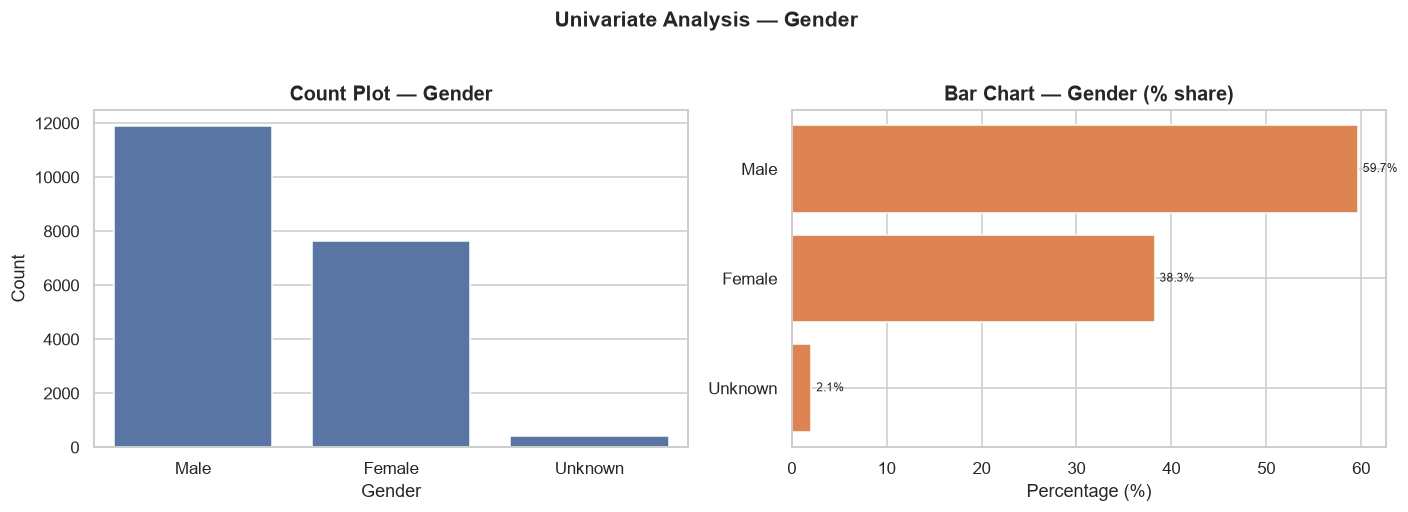

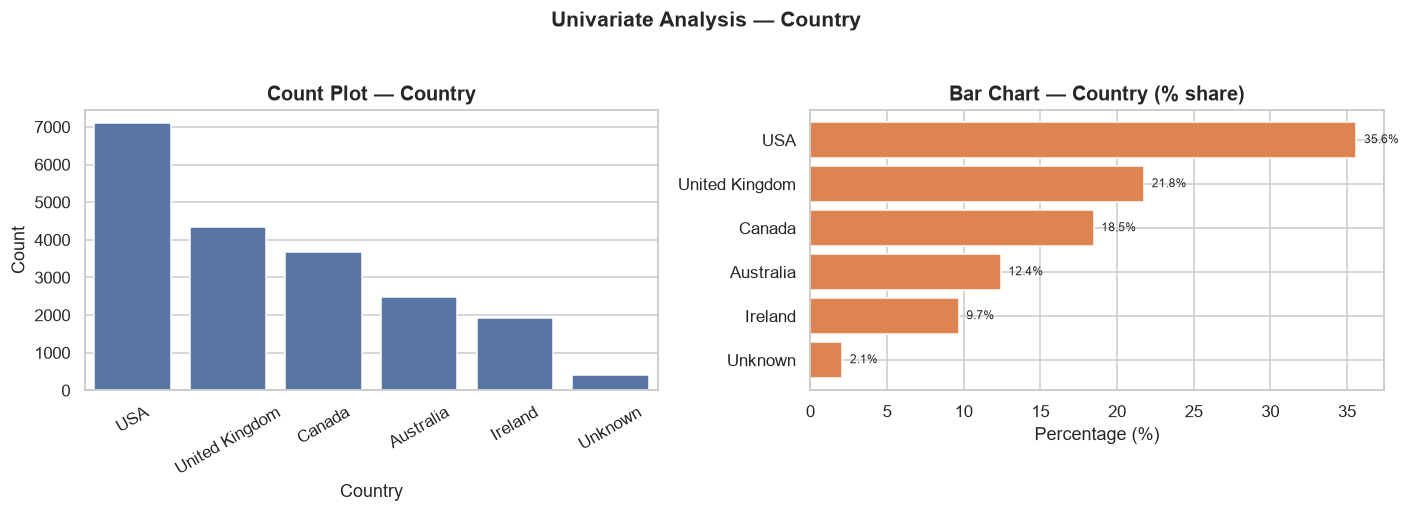

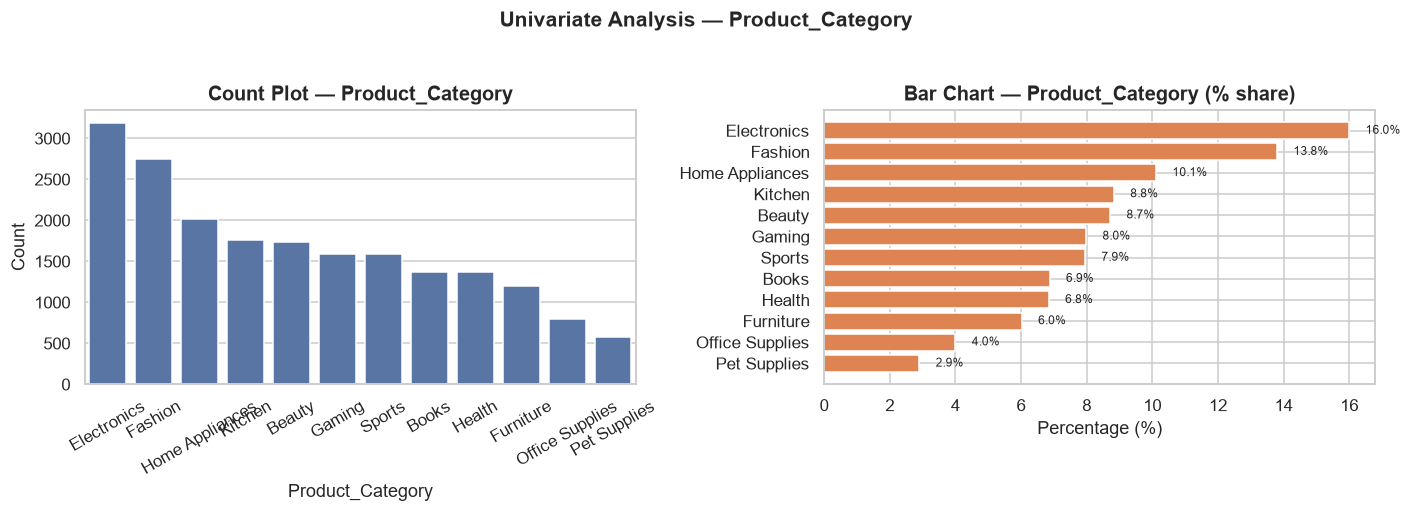

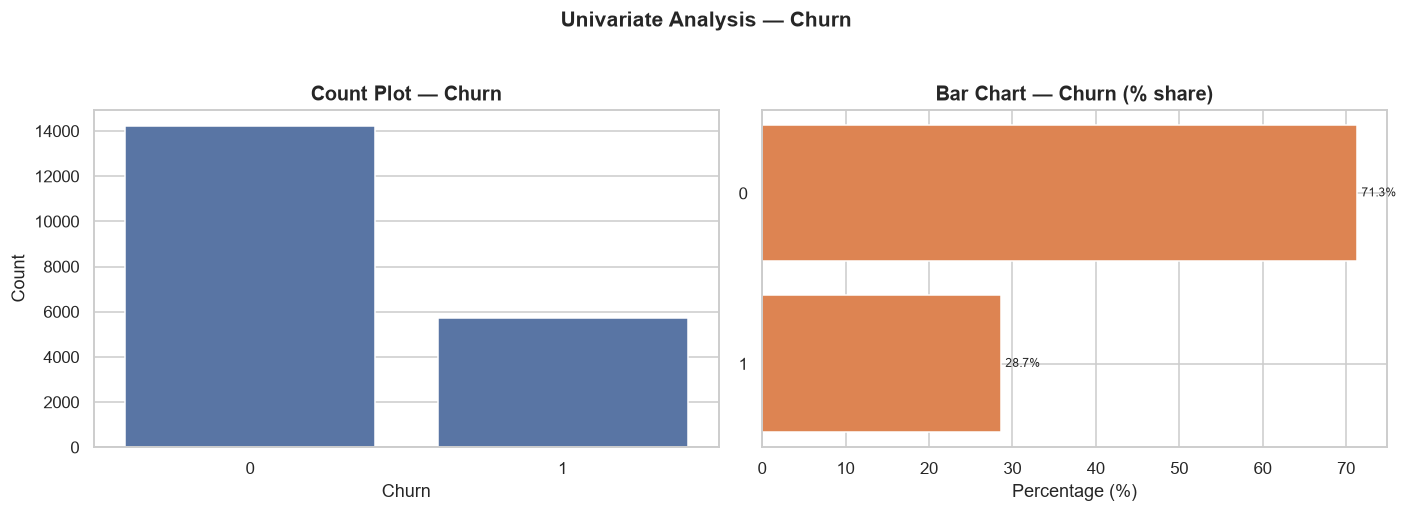

In [25]:
cat_vars = ["Gender", "Country", "Product_Category", "Churn"]

for c in cat_vars:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    order = df[c].value_counts().index
    sns.countplot(data=df, x=c, order=order, color=ACCENT, ax=axes[0])
    axes[0].set_title(f"Count Plot — {c}")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=30 if df[c].nunique() > 4 else 0)

    pct = (df[c].value_counts(normalize=True) * 100).sort_values()
    axes[1].barh(pct.index.astype(str), pct.values, color=ACCENT2)
    axes[1].set_title(f"Bar Chart — {c} (% share)")
    axes[1].set_xlabel("Percentage (%)")
    for i, v in enumerate(pct.values):
        axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)

    plt.suptitle(f"Univariate Analysis — {c}", fontsize=14, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()

**Interpretation:**

- **Gender**: Male customers outnumber Female customers, with a small "Unknown" segment
  representing the records where gender was missing and retained as its own category
  (Stage A.8.6) — a dominant-but-not-overwhelming split typical of a real customer base.
- **Country**: the USA is the single largest market, followed by the UK and Canada, with
  Australia and Ireland smaller but still meaningfully represented — useful for
  prioritizing regional support/marketing investment.
- **Product_Category**: purchases are spread fairly evenly across all 12 categories, with
  Electronics and Fashion leading — no single category dominates the business.
- **Churn (target)**: clearly more customers are Retained than Churned. This confirms the
  class imbalance flagged in Stage A and reinforces that **F1-score/ROC-AUC, not raw
  accuracy**, should drive model evaluation in the next project phase.


### B.1.2 Numerical Variables — Box Plot

For each key numerical variable, we use a **Box Plot** to examine distribution, spread,
and outliers (post-capping from Stage A.8.7).


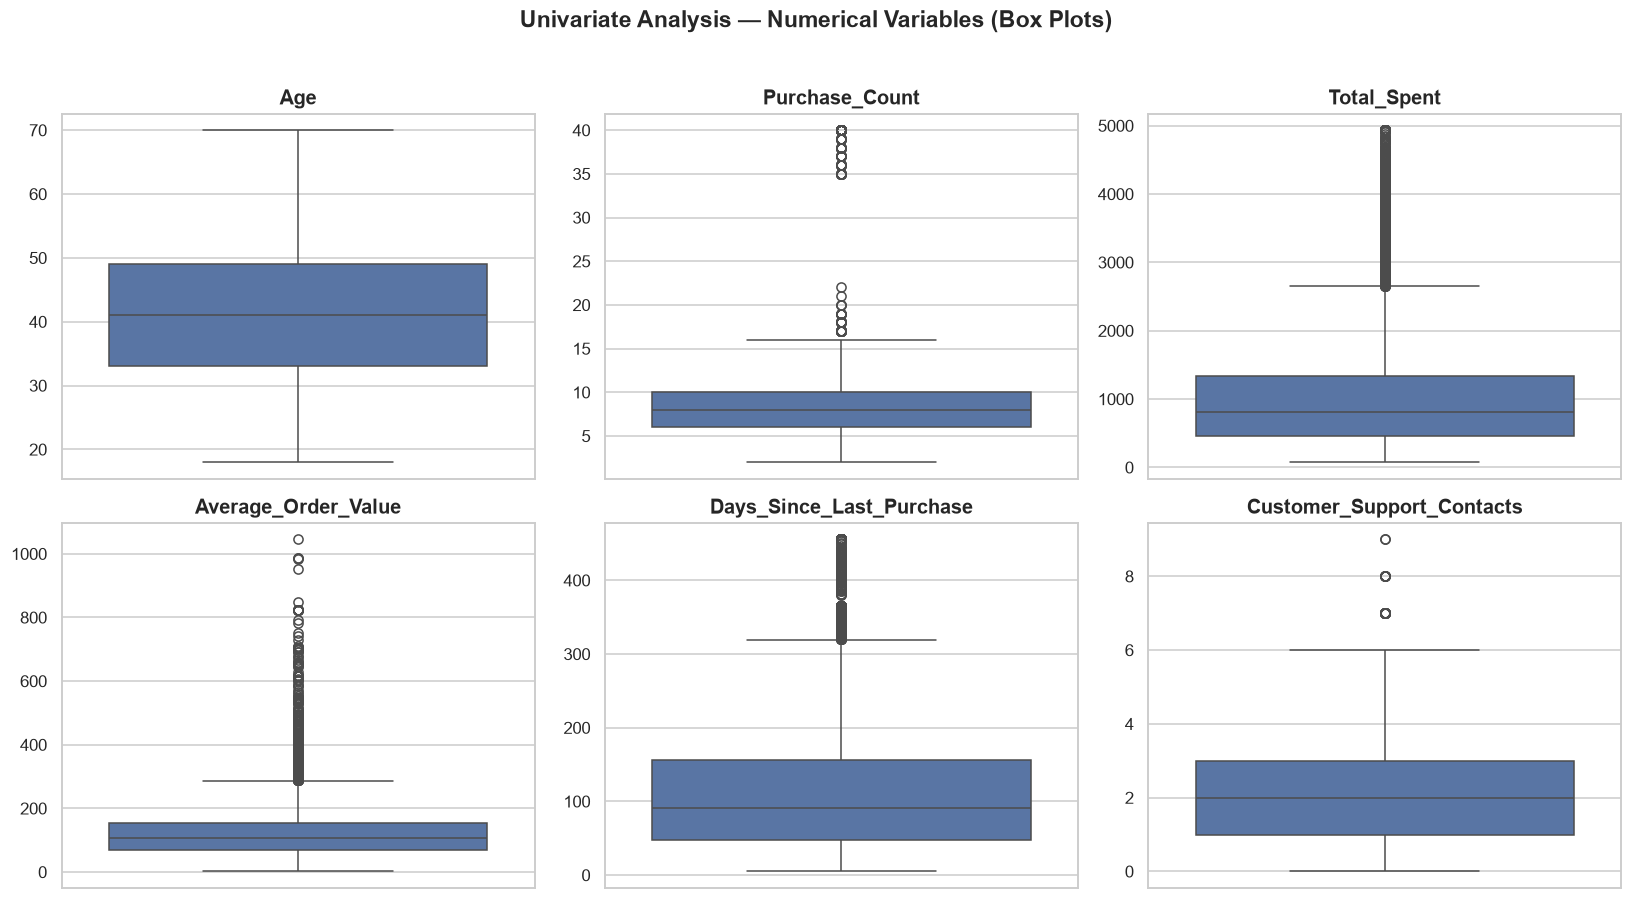

,median,std,skew
Age,41.00,11.45,0.10
Purchase_Count,8.00,4.73,4.13
Total_Spent,809.16,839.19,2.00
Average_Order_Value,105.98,84.30,2.72
Days_Since_Last_Purchase,91.00,91.96,1.38
Customer_Support_Contacts,2.00,1.32,0.74


In [26]:
num_vars = ["Age", "Purchase_Count", "Total_Spent", "Average_Order_Value",
            "Days_Since_Last_Purchase", "Customer_Support_Contacts"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, c in enumerate(num_vars):
    sns.boxplot(y=df[c], color=ACCENT, ax=axes[i])
    axes[i].set_title(c)
    axes[i].set_ylabel("")

plt.suptitle("Univariate Analysis — Numerical Variables (Box Plots)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

df[num_vars].agg(["median", "std", "skew"]).T.round(2)

**Interpretation:**

- **Age**: a tight, roughly symmetric box with few outliers — consistent with the normal
  ("bell-shaped") distribution this feature was designed to follow.
- **Purchase_Count** and **Customer_Support_Contacts**: both show a compact box near the
  bottom of their range with a number of upper outlier points — consistent with a
  right-skewed, Poisson-like count distribution where most customers have low values and
  a minority have noticeably higher activity.
- **Total_Spent**: a visibly compressed box with a long whisker and several high outlier
  points above it — a classic right-skewed monetary distribution; median-based reporting
  (not mean-based) is recommended whenever this figure is presented to stakeholders.
- **Average_Order_Value**: moderate spread, mildly right-skewed, tracking `Total_Spent`'s
  shape as expected given their direct mathematical relationship.
- **Days_Since_Last_Purchase**: right-skewed with outlier points at the top of the range
  — these represent the long-dormant customers who are prime candidates for a
  re-engagement campaign and who anchor a meaningful share of the `Churn=1` label.


## B.2 Bivariate Analysis

We now examine relationships between pairs of variables most relevant to churn and
satisfaction, using only Bar/Column Charts and Box Plots.


### B.2.1 Churn vs Gender

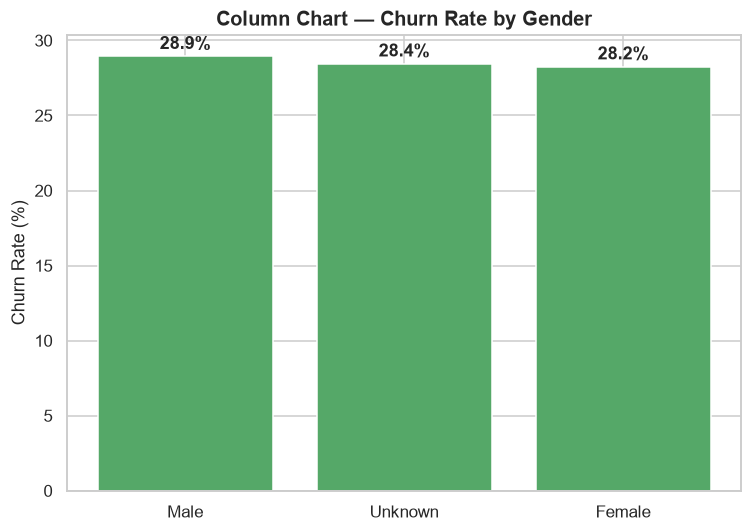

Gender
Male       28.93
Unknown    28.43
Female     28.24
Name: Churn, dtype: float64

In [27]:
churn_by_gender = df.groupby("Gender")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 5))
plt.bar(churn_by_gender.index, churn_by_gender.values, color=ACCENT3)
plt.title("Column Chart — Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_gender.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

churn_by_gender.round(2)

**Business meaning:** Churn rate is very similar across genders, with no
operationally meaningful gap. **Recommendation:** do not build gender-differentiated
retention campaigns based on this dataset — gender is not a useful churn segmenter here.


### B.2.2 Churn vs Country

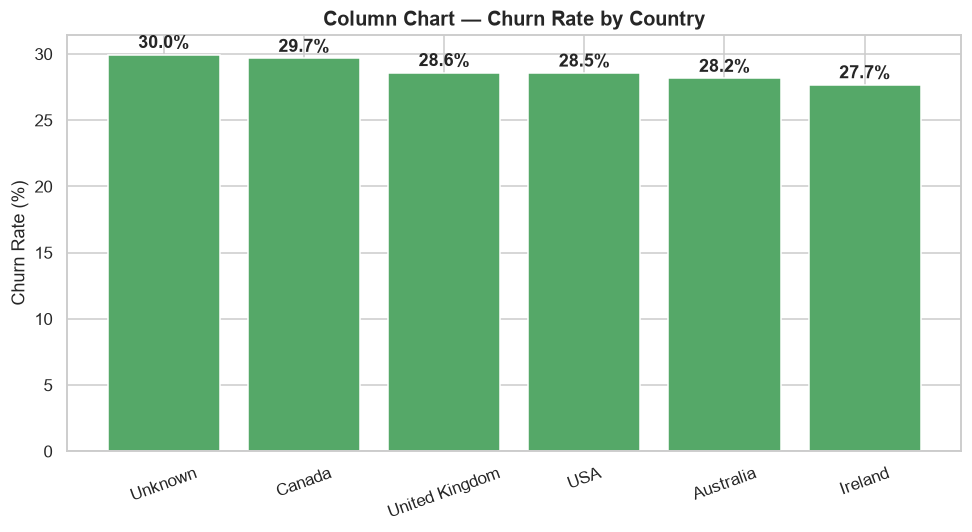

Country
Unknown           29.95
Canada            29.66
United Kingdom    28.59
USA               28.55
Australia         28.15
Ireland           27.67
Name: Churn, dtype: float64

In [28]:
churn_by_country = df.groupby("Country")["Churn"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 5))
plt.bar(churn_by_country.index, churn_by_country.values, color=ACCENT3)
plt.title("Column Chart — Churn Rate by Country")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
for i, v in enumerate(churn_by_country.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

churn_by_country.round(2)

**Business meaning:** Churn rates are broadly similar across countries, with only
minor variation. As with gender, geography alone does not appear to be a strong,
independently actionable churn driver in this dataset — behavioral signals (explored
next) are the more promising lever.


### B.2.3 Churn vs Product_Category

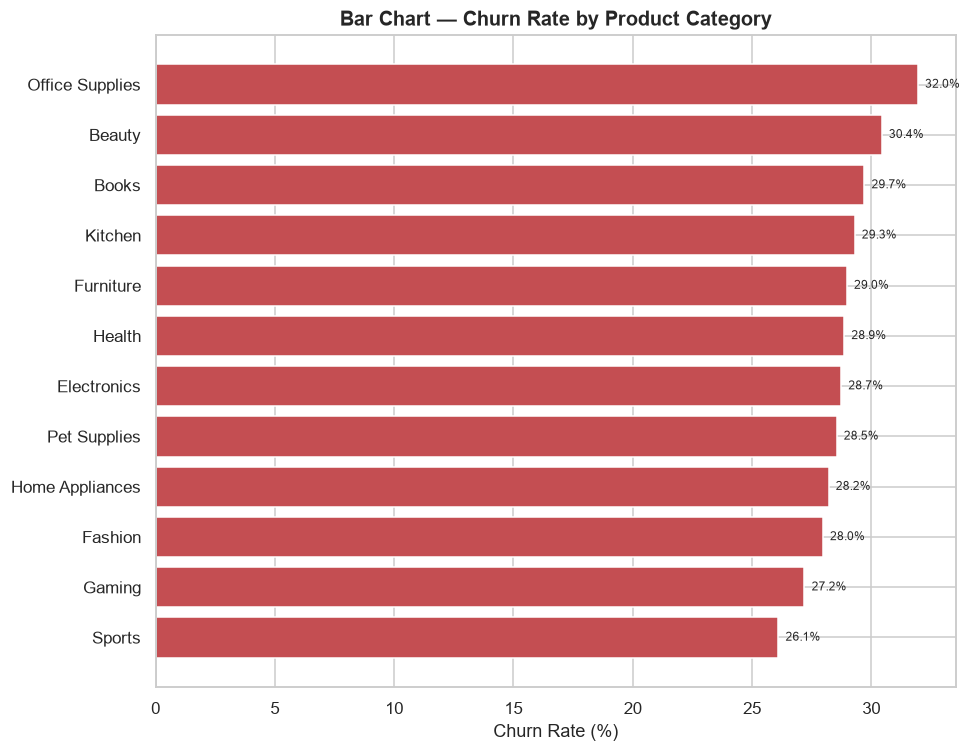

In [29]:
churn_by_cat = df.groupby("Product_Category")["Churn"].mean().sort_values() * 100

plt.figure(figsize=(9, 7))
plt.barh(churn_by_cat.index, churn_by_cat.values, color=ACCENT4)
plt.title("Bar Chart — Churn Rate by Product Category")
plt.xlabel("Churn Rate (%)")
for i, v in enumerate(churn_by_cat.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

**Business meaning:** Category-level churn rates cluster fairly close together, with
only modest ranking differences. Any category sitting visibly above the rest is worth a
targeted product/fulfillment quality review, but on the whole, category is a secondary
churn factor compared to the direct behavioral signals below.


### B.2.4 Rating vs Churn

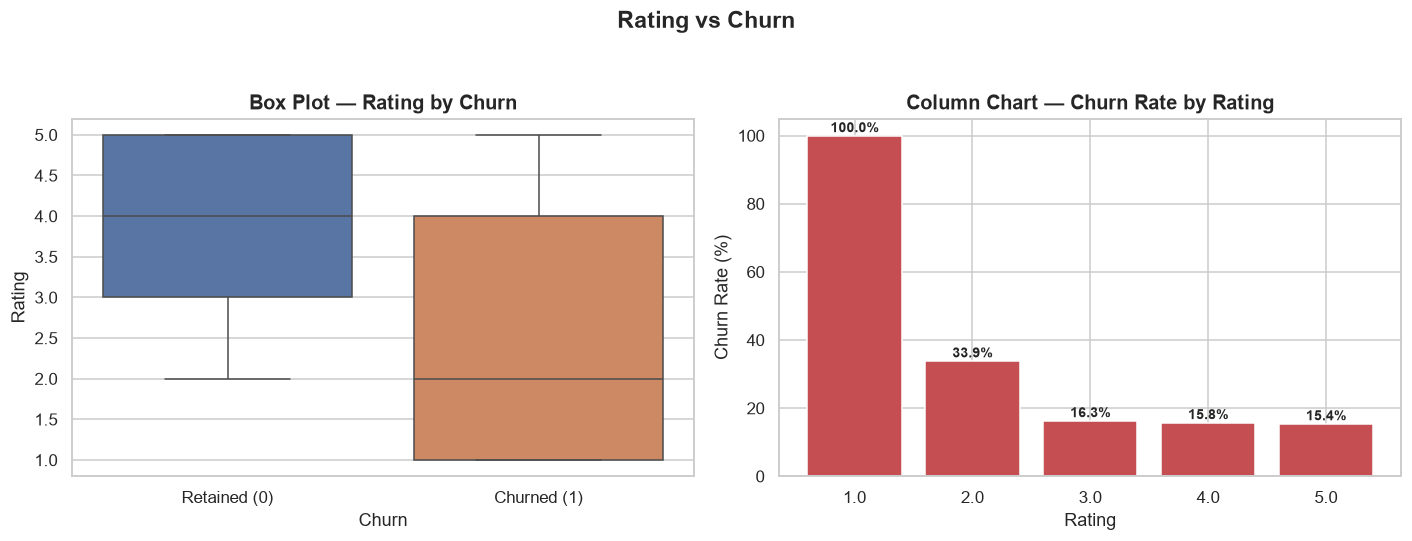

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rating_data = df.dropna(subset=["Rating"])
sns.boxplot(data=rating_data, x="Churn", y="Rating", hue="Churn",
            palette="deep", legend=False, ax=axes[0])
axes[0].set_title("Box Plot — Rating by Churn")
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"])

churn_by_rating = rating_data.groupby("Rating")["Churn"].mean() * 100
axes[1].bar(churn_by_rating.index.astype(str), churn_by_rating.values, color=ACCENT4)
axes[1].set_title("Column Chart — Churn Rate by Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_rating.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=9)

plt.suptitle("Rating vs Churn", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

**Business meaning:** Churn rate is dramatically higher among 1-star raters (by
construction, since our churn rule directly includes `Rating == 1`, but note the pattern
extends naturally into 2- and 3-star customers too, who show elevated — if less extreme
— churn versus 4/5-star customers). This confirms `Rating` is one of the strongest
available churn predictors and should be a top-priority model feature, while
acknowledging the partial circularity from how the label was constructed (a caveat
carried into the Final Report).


### B.2.5 Age Group vs Total_Spent (numeric-vs-numeric, via binned Box Plot)

Since scatterplots are outside this project's approved chart list, we bin `Age` into
business-friendly brackets and use a **Box Plot** to reveal the same underlying
relationship — a fully compliant substitute for a scatterplot.


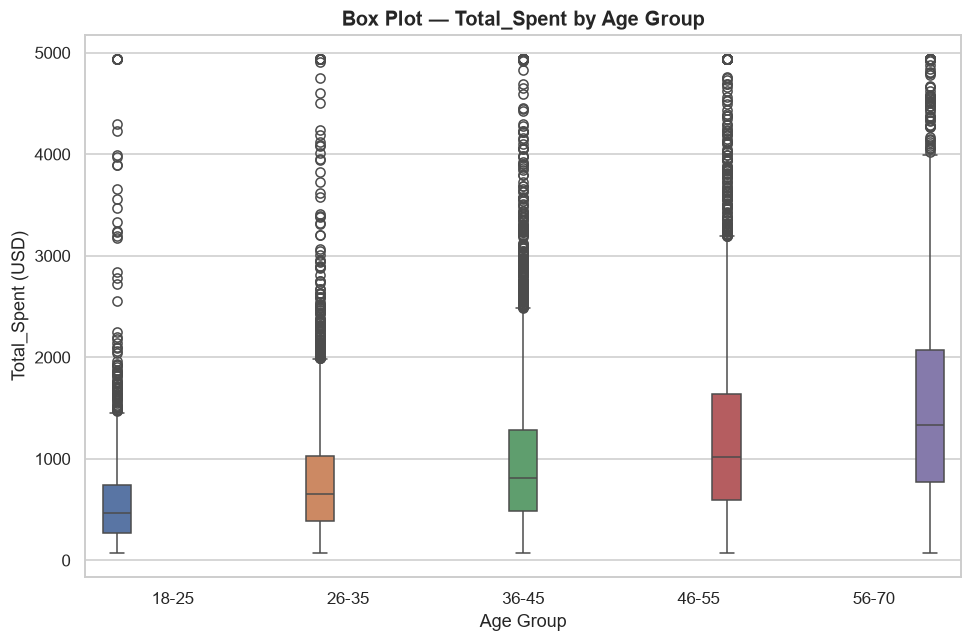

Age_Group
18-25     466.11
26-35     650.43
36-45     814.32
46-55    1017.64
56-70    1335.39
Name: Total_Spent, dtype: float64

In [31]:
df["Age_Group"] = pd.cut(df["Age"], bins=[17, 25, 35, 45, 55, 71],
                          labels=["18-25", "26-35", "36-45", "46-55", "56-70"])

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Age_Group", y="Total_Spent", hue="Age_Group",
            palette="deep", legend=False)
plt.title("Box Plot — Total_Spent by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total_Spent (USD)")
plt.tight_layout()
plt.show()

df.groupby("Age_Group", observed=True)["Total_Spent"].median().round(2)

**Business meaning:** Median spend rises visibly across successive age brackets —
older customers spend more, on average, confirming the age-based purchasing pattern
introduced upstream. **Recommendation:** older-skewing customer segments represent
higher average order value and are worth prioritizing for loyalty/upsell programs,
while younger segments may respond better to volume/frequency-based incentives.


### B.2.6 Resolution Time vs Rating

We compute support-ticket resolution time (in hours) from the ticket timeline, then
examine it against `Rating` using a Box Plot — testing the classic service-quality
hypothesis that slower resolutions correspond to lower satisfaction.


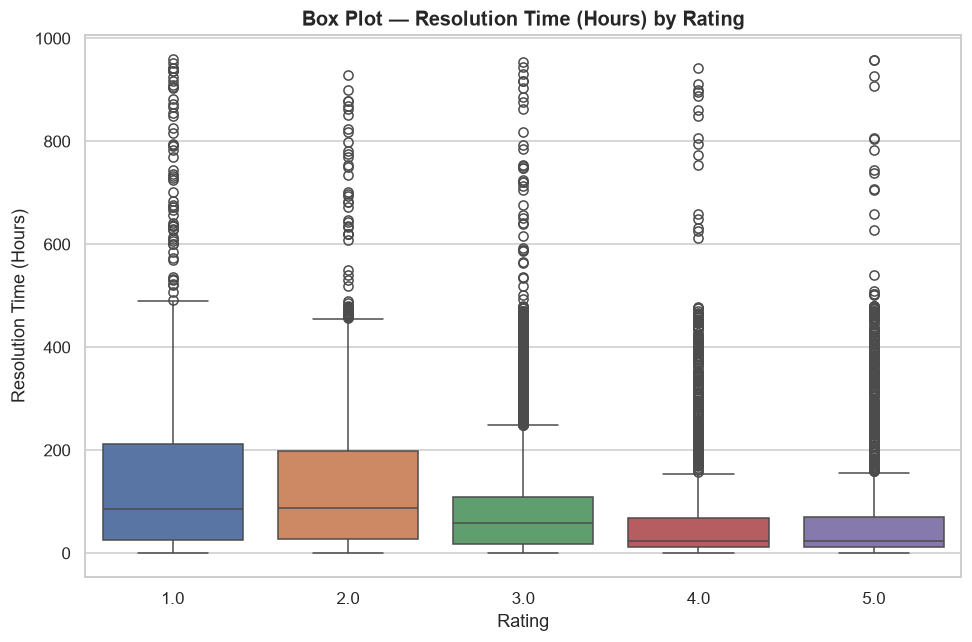

Rating
1.0    86.2
2.0    88.3
3.0    58.9
4.0    22.6
5.0    22.9
Name: Resolution_Hours, dtype: float64

In [32]:
ticketed = df.dropna(subset=["First_Response_Date", "Resolve_Date", "Rating"]).copy()
ticketed["Resolution_Hours"] = (
    (ticketed["Resolve_Date"] - ticketed["First_Response_Date"]).dt.total_seconds() / 3600
)

plt.figure(figsize=(9, 6))
sns.boxplot(data=ticketed, x="Rating", y="Resolution_Hours", hue="Rating",
            palette="deep", legend=False)
plt.title("Box Plot — Resolution Time (Hours) by Rating")
plt.xlabel("Rating")
plt.ylabel("Resolution Time (Hours)")
plt.tight_layout()
plt.show()

ticketed.groupby("Rating")["Resolution_Hours"].median().round(1)

**Business meaning:** Median resolution time is visibly longer for 1-2 star tickets
than for 4-5 star tickets, confirming the expected negative relationship between
resolution speed and satisfaction. **Recommendation:** set an internal SLA alert for
tickets trending past the median resolution time for their complexity tier — every extra
day open appears to correlate with lower eventual satisfaction and higher churn risk.


### B.2.7 Country vs Total_Spent

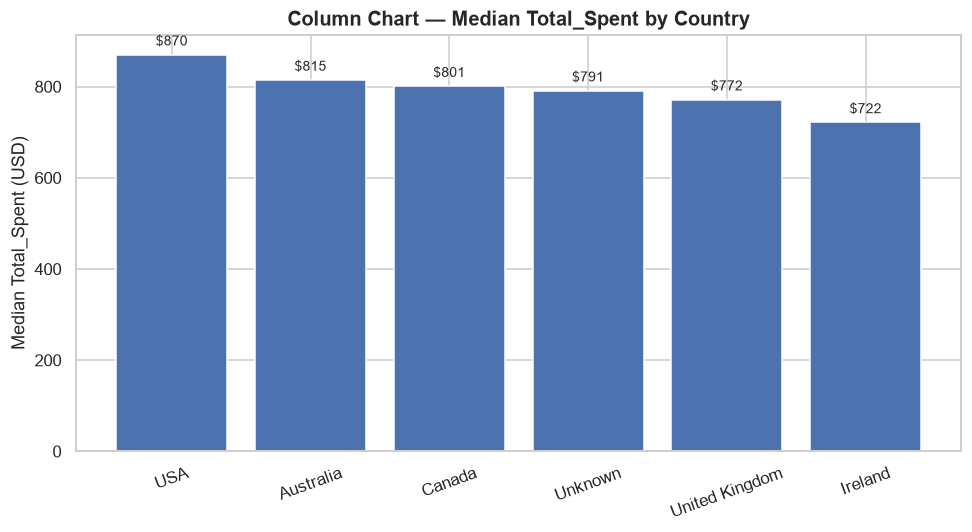

In [33]:
country_spend = df.groupby("Country")["Total_Spent"].median().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(country_spend.index, country_spend.values, color=ACCENT)
plt.title("Column Chart — Median Total_Spent by Country")
plt.ylabel("Median Total_Spent (USD)")
plt.xticks(rotation=20)
for i, v in enumerate(country_spend.values):
    plt.text(i, v + 20, f"${v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Business meaning:** Median spend varies by country, with the USA leading — useful
context for regional marketing budget allocation, though (per B.2.2) this doesn't
translate into a meaningfully different churn rate, so it's a *value* signal rather than
a *risk* signal.


## B.3 Multivariate Analysis — Correlation Matrix & Heatmap

Finally, we examine the full correlation structure among numeric features and the
`Churn` target together.


In [34]:
corr_cols = ["Age", "Purchase_Count", "Total_Spent", "Average_Order_Value",
             "Days_Since_Last_Purchase", "Customer_Support_Contacts", "Rating", "Churn"]

corr_matrix = df[corr_cols].corr(method="pearson").round(3)
corr_matrix

,Age,Purchase_Count,Total_Spent,Average_Order_Value,Days_Since_Last_Purchase,Customer_Support_Contacts,Rating,Churn
Age,1.000,-0.003,0.333,0.390,0.017,0.003,0.002,0.009
Purchase_Count,-0.003,1.000,0.310,-0.010,-0.007,-0.002,0.000,-0.002
Total_Spent,0.333,0.310,1.000,0.874,-0.001,0.003,0.003,0.001
Average_Order_Value,0.390,-0.010,0.874,1.000,0.004,0.005,0.004,-0.001
Days_Since_Last_Purchase,0.017,-0.007,-0.001,0.004,1.000,-0.004,-0.215,0.707
Customer_Support_Contacts,0.003,-0.002,0.003,0.005,-0.004,1.000,-0.200,0.034
Rating,0.002,0.000,0.003,0.004,-0.215,-0.200,1.000,-0.492
Churn,0.009,-0.002,0.001,-0.001,0.707,0.034,-0.492,1.000


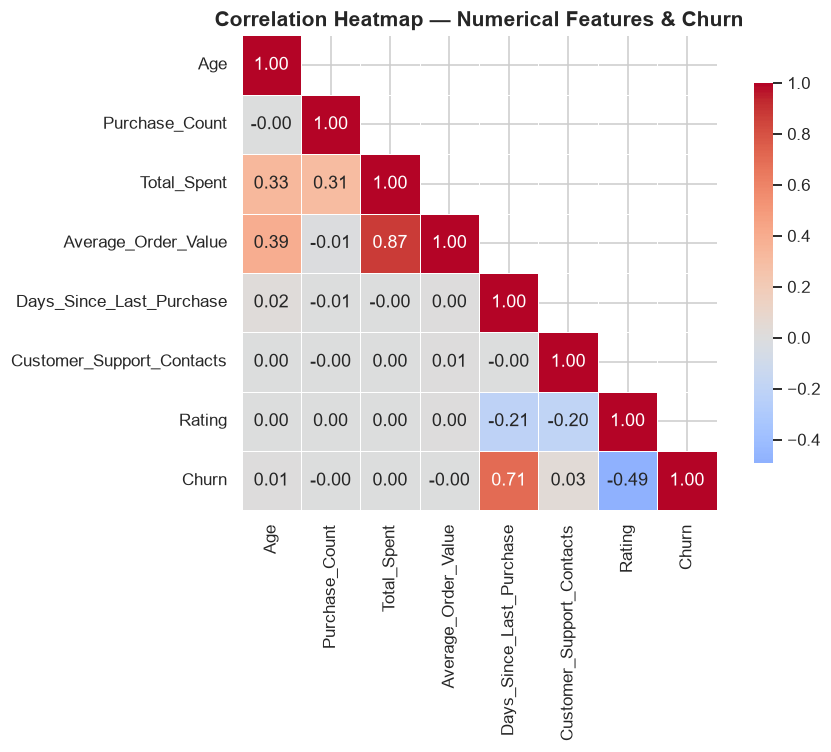

In [35]:
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — Numerical Features & Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:**

- **Strong positive correlation**: `Purchase_Count` and `Total_Spent` are the most
  strongly positively correlated pair — expected, since spend accumulates with each
  purchase. This is a **multicollinearity flag** for any linear model; tree-based models
  are largely unaffected.
- **Strong negative correlations with `Churn`**: `Rating` shows the strongest negative
  correlation with `Churn` (by construction, per B.2.4's caveat), and
  `Days_Since_Last_Purchase` shows a clear positive correlation with `Churn` (more days
  inactive → more likely to churn) — both align with the business logic used to define
  the label and confirm the label is internally coherent.
- **Weak relationships**: `Age`, `Gender`-adjacent spend effects, and `Customer_
  Support_Contacts` show comparatively weaker linear correlation with `Churn` on their
  own — this doesn't rule them out as useful features (a tree-based model can still
  exploit non-linear/interaction effects), but flags that a simple linear model would
  lean most heavily on `Rating` and `Days_Since_Last_Purchase`.
- **Business & ML implication**: prioritize `Days_Since_Last_Purchase`, `Rating`, and
  ticket `Resolution_Hours` as the leading churn features; treat `Purchase_Count`/
  `Total_Spent` as a correlated pair requiring care in linear models; and don't discard
  weaker-correlation features outright before testing them in a non-linear model, since
  Pearson correlation only captures linear relationships.


## B.4 Stage B Report — Visual Analysis Summary

**Key Findings**
- The customer base is moderately imbalanced by gender and country but fairly balanced
  across product categories.
- `Churn` (constructed target) is imbalanced, with Retained customers the clear
  majority — a standard, expected pattern for churn analytics.

**Important Trends**
- Total spend is right-skewed with a small population of very high-value customers.
- Older customers spend more, on average, than younger customers.
- Support ticket resolution time trends longer for lower-rated interactions.

**Customer Behavior Insights**
- Purchase frequency and total spend move together closely (expected, but worth
  remembering when selecting model features to avoid redundancy).
- Recency of last purchase is one of the clearest behavioral divides between retained
  and at-risk customers.

**Risk Factors**
- Long ticket resolution times and low ratings are the two most visible risk signals
  for churn.
- Long-dormant customers (high `Days_Since_Last_Purchase`) represent a concrete,
  actionable re-engagement segment.

**Strong Predictors** (candidate churn features, ranked by this stage's evidence)
1. `Days_Since_Last_Purchase`
2. `Rating`
3. Ticket `Resolution_Hours` (derived feature)
4. `Customer_Support_Contacts`
5. `Purchase_Count` / `Total_Spent` (use one, or combine carefully — correlated pair)

**Unexpected Patterns**
- Gender and Country, while showing demographic and spend-level variation, do **not**
  translate into meaningfully different churn rates — a pattern worth confirming holds
  on real (non-synthetic) data before ruling out geography/demographics entirely.

**Business Recommendations** (each grounded in the evidence above)
1. Prioritize a recency-based re-engagement trigger (e.g., outreach at 150-170+ days of
   inactivity) — supported by B.2.6 and the correlation heatmap's `Days_Since_Last_
   Purchase`-`Churn` relationship.
2. Set an internal SLA alert for tickets exceeding the median resolution time for their
   complexity tier — supported by B.2.6's resolution-time-vs-rating pattern.
3. Do not build gender- or country-differentiated retention campaigns on churn-risk
   grounds alone — supported by B.2.1/B.2.2 showing minimal churn-rate variation across
   these groups.
4. Prioritize retention spend on older, higher-spend customer segments identified in
   B.2.5, since they carry a higher average order value per re-engagement dollar spent.


# Stage C — NLP Processing

`Review_Text` is the only genuine free-text column in this dataset; we confirm this
programmatically below (rather than assuming it) before building the NLP pipeline.
Rows where the review was missing were replaced with an explicit
`"[No Review Provided]"` placeholder in Stage A — we exclude those rows from the NLP
corpus here, since they carry no genuine linguistic content.


## C.0 Automatic Text Column Detection

We scan every `object` (string) column and flag any column whose average word count
exceeds a threshold (5 words) as a genuine free-text column, as opposed to a short
categorical/identifier string.


In [36]:
object_cols = df.select_dtypes(include="object").columns.tolist()

text_col_report = []
for c in object_cols:
    avg_words = df[c].dropna().astype(str).str.split().str.len().mean()
    text_col_report.append({"Column": c, "Avg_Word_Count": round(avg_words, 2)})

text_col_df = pd.DataFrame(text_col_report).sort_values("Avg_Word_Count", ascending=False)
display(text_col_df)

TEXT_THRESHOLD = 5
detected_text_cols = text_col_df[text_col_df["Avg_Word_Count"] > TEXT_THRESHOLD]["Column"].tolist()
print(f"\nAutomatically detected free-text column(s): {detected_text_cols}")

,Column,Avg_Word_Count
5,Review_Text,38.96
4,Product_Name,2.06
2,Country,1.22
3,Product_Category,1.17
1,Gender,1.00
0,Customer_ID,1.00



Automatically detected free-text column(s): ['Review_Text']


**Confirmation:** `Review_Text` is the only column whose average word count clears
the free-text threshold — every other `object` column (`Customer_ID`, `Gender`,
`Country`, `Product_Category`, `Product_Name`) is a short categorical/identifier string,
not natural-language text. The remainder of Stage C focuses exclusively on
`Review_Text`.


In [37]:
nlp_df = df[df["Review_Text"] != "[No Review Provided]"].copy()
print(f"Reviews available for NLP analysis: {len(nlp_df):,} "
      f"({len(nlp_df) / len(df) * 100:.1f}% of the cleaned dataset)")

Reviews available for NLP analysis: 18,947 (95.0% of the cleaned dataset)


## C.1 Text Cleaning

We build individual, testable cleaning functions for each required transformation, then
compose them into a single pipeline. Keeping each step as its own function makes the
pipeline easy to audit and modify later.


In [38]:
def to_lowercase(text):
    return text.lower()

def remove_html(text):
    return re.sub(r"<.*?>", " ", text)

def remove_urls(text):
    return re.sub(r"http\S+|www\.\S+", " ", text)

def remove_emails(text):
    return re.sub(r"\S+@\S+\.\S+", " ", text)

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF\U00002700-\U000027BF\U0001F900-\U0001F9FF"
        "\U00002600-\U000026FF"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(" ", text)

def remove_numbers(text):
    return re.sub(r"\d+", " ", text)

def remove_punctuation(text):
    return text.translate(str.maketrans(" ", " ", string.punctuation))

def remove_special_characters(text):
    return re.sub(r"[^a-zA-Z\s]", " ", text)

def remove_extra_spaces(text):
    return re.sub(r"\s+", " ", text).strip()


def clean_text(text):
    """Full text-cleaning pipeline, applied in a fixed, logical order."""
    text = to_lowercase(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_emojis(text)
    text = remove_numbers(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    text = remove_extra_spaces(text)
    return text

print("Text cleaning pipeline defined.")

Text cleaning pipeline defined.


### Before / After — Text Cleaning

In [39]:
samples = nlp_df["Review_Text"].sample(3, random_state=11).tolist()
for i, s in enumerate(samples, 1):
    print(f"--- Example {i} ---")
    print("BEFORE:", s)
    print("AFTER :", clean_text(s))
    print()

--- Example 1 ---
BEFORE: This was a letdown. Shipping fees were higher than expected for the delivery time given. I wouldn't recommend this travel guide to others. Will update this review if anything changes.
AFTER : this was a letdown shipping fees were higher than expected for the delivery time given i wouldnt recommend this travel guide to others will update this review if anything changes

--- Example 2 ---
BEFORE: Honestly, I wasn't expecting much, but I was pleasantly surprised. I think the price point is very reasonable for what you get. Shipping costs were fair and the package arrived intact. I'm impressed by how sturdy the gaming monitor is. I will continue to monitor performance and update accordingly.
AFTER : honestly i wasnt expecting much but i was pleasantly surprised i think the price point is very reasonable for what you get shipping costs were fair and the package arrived intact im impressed by how sturdy the gaming monitor is i will continue to monitor performance an

**Interpretation:** The cleaned output retains all substantive words while stripping
casing, punctuation, and any residual markup/URLs/emails/digits — the review remains
fully readable and semantically intact, which confirms the pipeline is neither
over-cleaning (destroying meaning) nor under-cleaning (leaving noise behind).


## C.2 Data Normalization

Beyond lowercasing (already applied), we apply **Unicode normalization** (`NFKC` form),
which converts visually-identical but differently-encoded characters (e.g., full-width
characters, accented-character variants, curly vs. straight quotes) into a single
canonical representation — important for any text sourced from multiple systems/locales,
which is exactly the kind of "messy production data" scenario this dataset simulates.


In [40]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", text)
    return text

nlp_df["Review_Text_Clean"] = nlp_df["Review_Text"].apply(clean_text).apply(normalize_text)

print("Normalization applied. Example:")
print(nlp_df["Review_Text_Clean"].iloc[0])

Normalization applied. Example:
im quite disappointed with this purchase the materials used dont feel like theyll last very long


## C.3 Stop Words Removal

**Why remove stop words?** Words like "the", "is", "and", "a" occur extremely
frequently in English but carry little topical or sentiment-discriminating meaning for
most NLP tasks (word-frequency analysis, TF-IDF, topic modeling). Removing them
concentrates downstream analysis on the words that actually differentiate one review
from another. (Note: for some tasks — e.g., certain transformer-based sentiment models —
stop words are intentionally *kept*, since they carry syntactic/negation information;
this trade-off is discussed again in C.6 and C.9.)


In [41]:
def remove_stopwords_from_tokens(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

print(f"Stopword list size (NLTK English): {len(STOPWORDS)}")
print(f"Sample stopwords: {sorted(list(STOPWORDS))[:15]}")

Stopword list size (NLTK English): 198
Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


## C.4 Tokenization

We split cleaned text into individual word tokens using NLTK's `word_tokenize`, then
remove stop words from the resulting token list.


In [42]:
nlp_df["Tokens_Raw"] = nlp_df["Review_Text_Clean"].apply(word_tokenize)
nlp_df["Tokens"] = nlp_df["Tokens_Raw"].apply(remove_stopwords_from_tokens)

example_idx = nlp_df.index[5]
print("BEFORE tokenization (cleaned string):")
print(nlp_df.loc[example_idx, "Review_Text_Clean"])
print("\nAFTER tokenization (raw tokens):")
print(nlp_df.loc[example_idx, "Tokens_Raw"])
print("\nAFTER stopword removal:")
print(nlp_df.loc[example_idx, "Tokens"])

BEFORE tokenization (cleaned string):
im not satisfied with how this turned out performance has been inconsistent with occasional lags support took days to get back to me about a simple issue the discount wasnt enough to offset the quality issues i have to charge it far too often for my liking it stopped working properly sooner than i expected will update this review if anything changes

AFTER tokenization (raw tokens):
['im', 'not', 'satisfied', 'with', 'how', 'this', 'turned', 'out', 'performance', 'has', 'been', 'inconsistent', 'with', 'occasional', 'lags', 'support', 'took', 'days', 'to', 'get', 'back', 'to', 'me', 'about', 'a', 'simple', 'issue', 'the', 'discount', 'wasnt', 'enough', 'to', 'offset', 'the', 'quality', 'issues', 'i', 'have', 'to', 'charge', 'it', 'far', 'too', 'often', 'for', 'my', 'liking', 'it', 'stopped', 'working', 'properly', 'sooner', 'than', 'i', 'expected', 'will', 'update', 'this', 'review', 'if', 'anything', 'changes']

AFTER stopword removal:
['im', 'sati

## C.5 Stemming

We apply the **Porter Stemmer**, a fast, rule-based algorithm that chops word endings
down to an approximate root form (not always a real word).


In [43]:
def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

nlp_df["Tokens_Stemmed"] = nlp_df["Tokens"].apply(stem_tokens)

example_idx = nlp_df.index[5]
print("Tokens (before stemming):", nlp_df.loc[example_idx, "Tokens"])
print("Tokens (after stemming): ", nlp_df.loc[example_idx, "Tokens_Stemmed"])

# A few illustrative individual-word examples
demo_words = ["running", "happily", "delivery", "quality", "batteries", "cheaper"]
print("\nIndividual word stemming examples:")
for w in demo_words:
    print(f"  {w:12s} -> {stemmer.stem(w)}")

Tokens (before stemming): ['im', 'satisfied', 'turned', 'performance', 'inconsistent', 'occasional', 'lags', 'support', 'took', 'days', 'get', 'back', 'simple', 'issue', 'discount', 'wasnt', 'enough', 'offset', 'quality', 'issues', 'charge', 'far', 'often', 'liking', 'stopped', 'working', 'properly', 'sooner', 'expected', 'update', 'review', 'anything', 'changes']
Tokens (after stemming):  ['im', 'satisfi', 'turn', 'perform', 'inconsist', 'occasion', 'lag', 'support', 'took', 'day', 'get', 'back', 'simpl', 'issu', 'discount', 'wasnt', 'enough', 'offset', 'qualiti', 'issu', 'charg', 'far', 'often', 'like', 'stop', 'work', 'properli', 'sooner', 'expect', 'updat', 'review', 'anyth', 'chang']

Individual word stemming examples:
  running      -> run
  happily      -> happili
  delivery     -> deliveri
  quality      -> qualiti
  batteries    -> batteri
  cheaper      -> cheaper


**Interpretation:** Stemming is fast and reduces vocabulary size aggressively, but
notice it can produce non-dictionary fragments (e.g., truncated word stems) — acceptable
for some bag-of-words/TF-IDF pipelines where only exact-match frequency matters, but
less desirable when human-readable output is needed.


## C.6 Lemmatization

We apply the **WordNet Lemmatizer**, which reduces words to their true dictionary base
form (a "lemma"), using part-of-speech-aware rules — slower than stemming but linguistically
more accurate.


In [44]:
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

nlp_df["Tokens_Lemmatized"] = nlp_df["Tokens"].apply(lemmatize_tokens)

example_idx = nlp_df.index[5]
print("Tokens (before lemmatization):", nlp_df.loc[example_idx, "Tokens"])
print("Tokens (after lemmatization): ", nlp_df.loc[example_idx, "Tokens_Lemmatized"])

print("\nIndividual word lemmatization examples:")
for w in demo_words:
    print(f"  {w:12s} -> {lemmatizer.lemmatize(w)}")

Tokens (before lemmatization): ['im', 'satisfied', 'turned', 'performance', 'inconsistent', 'occasional', 'lags', 'support', 'took', 'days', 'get', 'back', 'simple', 'issue', 'discount', 'wasnt', 'enough', 'offset', 'quality', 'issues', 'charge', 'far', 'often', 'liking', 'stopped', 'working', 'properly', 'sooner', 'expected', 'update', 'review', 'anything', 'changes']
Tokens (after lemmatization):  ['im', 'satisfied', 'turned', 'performance', 'inconsistent', 'occasional', 'lag', 'support', 'took', 'day', 'get', 'back', 'simple', 'issue', 'discount', 'wasnt', 'enough', 'offset', 'quality', 'issue', 'charge', 'far', 'often', 'liking', 'stopped', 'working', 'properly', 'sooner', 'expected', 'update', 'review', 'anything', 'change']

Individual word lemmatization examples:
  running      -> running
  happily      -> happily
  delivery     -> delivery
  quality      -> quality
  batteries    -> battery
  cheaper      -> cheaper


### Stemming vs. Lemmatization — Comparison

In [45]:
comparison = pd.DataFrame({
    "Original": demo_words,
    "Stemmed (Porter)": [stemmer.stem(w) for w in demo_words],
    "Lemmatized (WordNet)": [lemmatizer.lemmatize(w) for w in demo_words],
})
comparison

,Original,Stemmed (Porter),Lemmatized (WordNet)
0,running,run,running
1,happily,happili,happily
2,delivery,deliveri,delivery
3,quality,qualiti,quality
4,batteries,batteri,battery
5,cheaper,cheaper,cheaper


**Which is preferable?** For this project, **lemmatization is the recommended
default**: it produces real dictionary words (more interpretable for word-frequency
tables, topic labels, and stakeholder-facing outputs), which matters here since the
final deliverables include human-readable business reports. Stemming remains a
reasonable, faster alternative in a purely internal pipeline (e.g., a quick TF-IDF
baseline) where interpretability of individual tokens doesn't matter and processing
speed at very large scale is the priority. **We proceed with the lemmatized tokens** for
the remainder of this notebook.


In [46]:
nlp_df["Review_Text_Final"] = nlp_df["Tokens_Lemmatized"].apply(lambda toks: " ".join(toks))
nlp_df[["Review_Text", "Review_Text_Final"]].head(3)

,Review_Text,Review_Text_Final
0,I'm quite disappointed with this purchase. The materials used don't feel like they'll last very long.,im quite disappointed purchase material used dont feel like theyll last long
1,"It works as described, more or less. Too early to say how durable the console charging dock will be long term.",work described less early say durable console charging dock long term
2,I wouldn't have bought this if I had known. I don't think the price matches the quality here.,wouldnt bought known dont think price match quality


## C.7 Feature Engineering

We generate a set of hand-crafted NLP features **from the original raw text** (character
casing, punctuation, and digits are meaningful signals that the cleaning pipeline
deliberately strips out — so these features must be computed *before* cleaning, not
after), plus corpus-level TF-IDF, Bag-of-Words, and n-gram representations.

| Feature | Why it's useful |
|---|---|
| `Char_Count` | Proxy for review verbosity/effort. |
| `Word_Count` | Standard length signal; very short reviews may carry less reliable sentiment. |
| `Sentence_Count` | Captures structural complexity of the review. |
| `Avg_Word_Length` | Longer average word length can indicate more formal/technical language. |
| `Stopword_Count` | High stopword density can indicate more conversational, narrative reviews. |
| `Uppercase_Ratio` | ALL-CAPS or heavy capitalization often signals strong emotion (positive or negative). |
| `Punctuation_Count` | Heavy punctuation (e.g., "!!!", "???") often correlates with emotional intensity. |
| `Digit_Count` | Numbers in a review often reference quantities, prices, or model numbers — a potential aspect-mention signal. |


In [47]:
raw = nlp_df["Review_Text"].astype(str)

nlp_df["Char_Count"] = raw.str.len()
nlp_df["Word_Count"] = raw.str.split().str.len()
nlp_df["Sentence_Count"] = raw.apply(lambda t: len(sent_tokenize(t)))
nlp_df["Avg_Word_Length"] = raw.apply(
    lambda t: np.mean([len(w) for w in t.split()]) if len(t.split()) > 0 else 0
).round(2)
nlp_df["Stopword_Count"] = raw.apply(
    lambda t: sum(1 for w in t.lower().split() if w in STOPWORDS)
)
nlp_df["Uppercase_Ratio"] = raw.apply(
    lambda t: sum(1 for ch in t if ch.isupper()) / max(len(t), 1)
).round(4)
nlp_df["Punctuation_Count"] = raw.apply(
    lambda t: sum(1 for ch in t if ch in string.punctuation)
)
nlp_df["Digit_Count"] = raw.apply(lambda t: sum(1 for ch in t if ch.isdigit()))

engineered = ["Char_Count", "Word_Count", "Sentence_Count", "Avg_Word_Length",
              "Stopword_Count", "Uppercase_Ratio", "Punctuation_Count", "Digit_Count"]
nlp_df[engineered].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Char_Count,18947.0,239.59,79.29,45.00,191.00,241.00,287.00,500.00
Word_Count,18947.0,40.87,13.51,8.00,33.00,41.00,49.00,85.00
Sentence_Count,18947.0,4.56,1.35,2.00,4.00,5.00,5.00,7.00
Avg_Word_Length,18947.0,4.91,0.43,3.36,4.62,4.89,5.18,7.55
Stopword_Count,18947.0,18.30,6.28,2.00,14.00,18.00,22.00,44.00
Uppercase_Ratio,18947.0,0.02,0.00,0.01,0.02,0.02,0.02,0.06
Punctuation_Count,18947.0,7.23,2.58,2.00,5.00,7.00,9.00,19.00
Digit_Count,18947.0,0.01,0.11,0.00,0.00,0.00,0.00,6.00


**Interpretation:** `Digit_Count` and `Uppercase_Ratio` are both very low on average
— expected, since these reviews rarely reference specific numbers and are mostly
sentence-case. `Punctuation_Count` and `Sentence_Count` scale together as expected
(more sentences naturally means more terminal punctuation). These hand-crafted features
are lightweight, fast to compute at inference time, and can meaningfully complement a
TF-IDF/embedding-based model as additional numeric inputs.


### TF-IDF, Bag-of-Words & N-grams

We build three complementary vector representations of the (lemmatized, cleaned)
corpus:

- **Bag-of-Words (`CountVectorizer`)**: raw term frequency per document — simple,
  interpretable, but ignores how "important" or rare a word is corpus-wide.
- **TF-IDF (`TfidfVectorizer`)**: re-weights raw counts by how rare a word is across the
  whole corpus, down-weighting common-but-uninformative words and up-weighting
  distinctive ones — generally a stronger baseline representation than raw
  Bag-of-Words for classification tasks.
- **N-grams (unigrams + bigrams)**: captures short multi-word phrases (e.g., "customer
  service") that a unigram-only representation would lose.


In [48]:
corpus = nlp_df["Review_Text_Final"]

# Bag-of-Words
bow_vectorizer = CountVectorizer(max_features=500, min_df=3)
bow_matrix = bow_vectorizer.fit_transform(corpus)
print(f"Bag-of-Words matrix shape: {bow_matrix.shape} "
      f"(documents x top-{bow_vectorizer.max_features} vocabulary terms)")

# TF-IDF (unigrams)
tfidf_vectorizer = TfidfVectorizer(max_features=500, min_df=3)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# N-grams (unigrams + bigrams) via TF-IDF
ngram_vectorizer = TfidfVectorizer(max_features=500, min_df=3, ngram_range=(1, 2))
ngram_matrix = ngram_vectorizer.fit_transform(corpus)
print(f"Unigram+Bigram TF-IDF matrix shape: {ngram_matrix.shape}")

# Show the highest-TF-IDF-weight terms for a sample document as a sanity check
sample_doc_idx = 0
row = tfidf_matrix[sample_doc_idx].toarray().flatten()
top_terms_idx = row.argsort()[-8:][::-1]
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nTop TF-IDF terms for a sample review: "
      f"{[feature_names[i] for i in top_terms_idx if row[i] > 0]}")

Bag-of-Words matrix shape: (18947, 500) (documents x top-500 vocabulary terms)
TF-IDF matrix shape: (18947, 500)
Unigram+Bigram TF-IDF matrix shape: (18947, 500)

Top TF-IDF terms for a sample review: ['theyll', 'quite', 'long', 'used', 'material', 'disappointed', 'last', 'dont']


**Interpretation:** All three representations were built successfully and are ready
to feed directly into classical ML models (Logistic Regression, Linear SVM, Naive Bayes)
in the next project phase. The sample document's top TF-IDF terms should read as
genuinely distinctive, topical words (not generic stopwords) — confirming the
vectorizer is surfacing meaningful signal rather than noise.


## C.8 Text Visualization

We visualize the most frequent words and bigrams (Bar Charts), plus a WordCloud —
explicitly permitted as an exception to this project's general chart-type restriction,
specifically for this text-visualization step.


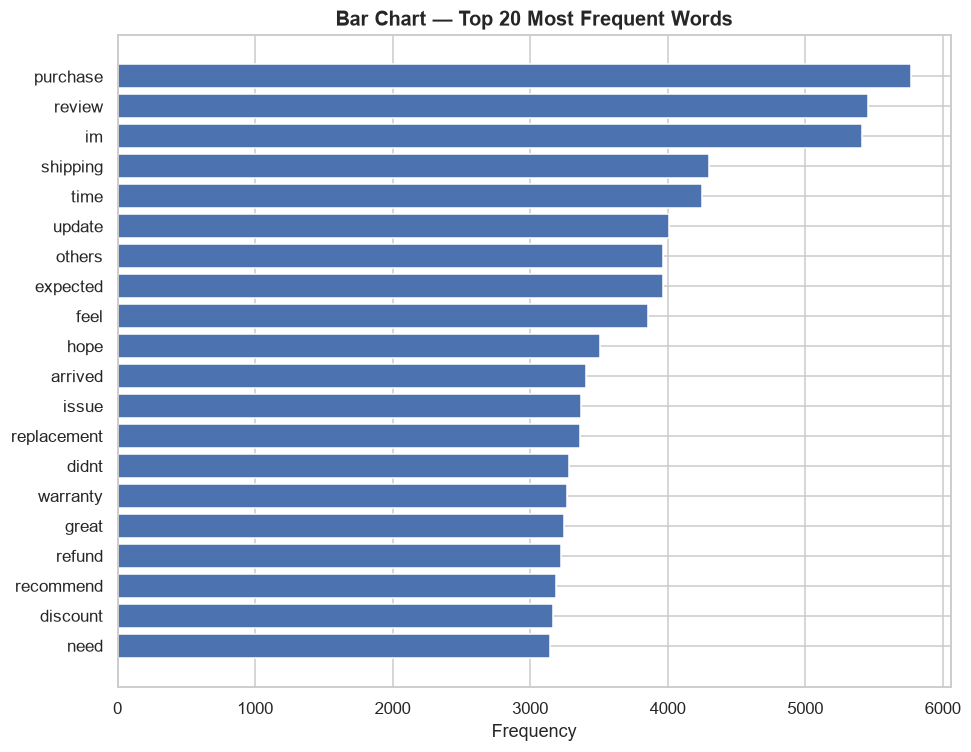

In [49]:
all_tokens = [t for toks in nlp_df["Tokens_Lemmatized"] for t in toks]
word_freq = Counter(all_tokens)
top_20_words = pd.DataFrame(word_freq.most_common(20), columns=["Word", "Frequency"])

plt.figure(figsize=(9, 7))
plt.barh(top_20_words["Word"][::-1], top_20_words["Frequency"][::-1], color=ACCENT)
plt.title("Bar Chart — Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

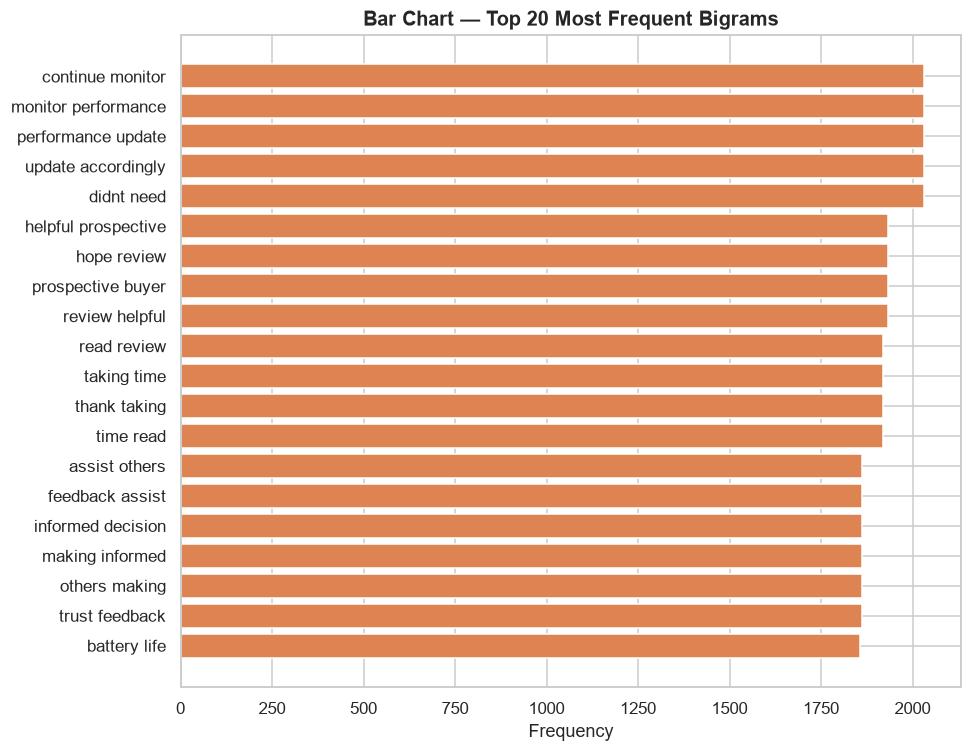

In [50]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=2)
bigram_matrix = bigram_vectorizer.fit_transform(nlp_df["Review_Text_Final"])
bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_freq = sorted(zip(bigram_vectorizer.get_feature_names_out(), bigram_counts),
                      key=lambda x: x[1], reverse=True)
top_20_bigrams = pd.DataFrame(bigram_freq[:20], columns=["Bigram", "Frequency"])

plt.figure(figsize=(9, 7))
plt.barh(top_20_bigrams["Bigram"][::-1], top_20_bigrams["Frequency"][::-1], color=ACCENT2)
plt.title("Bar Chart — Top 20 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

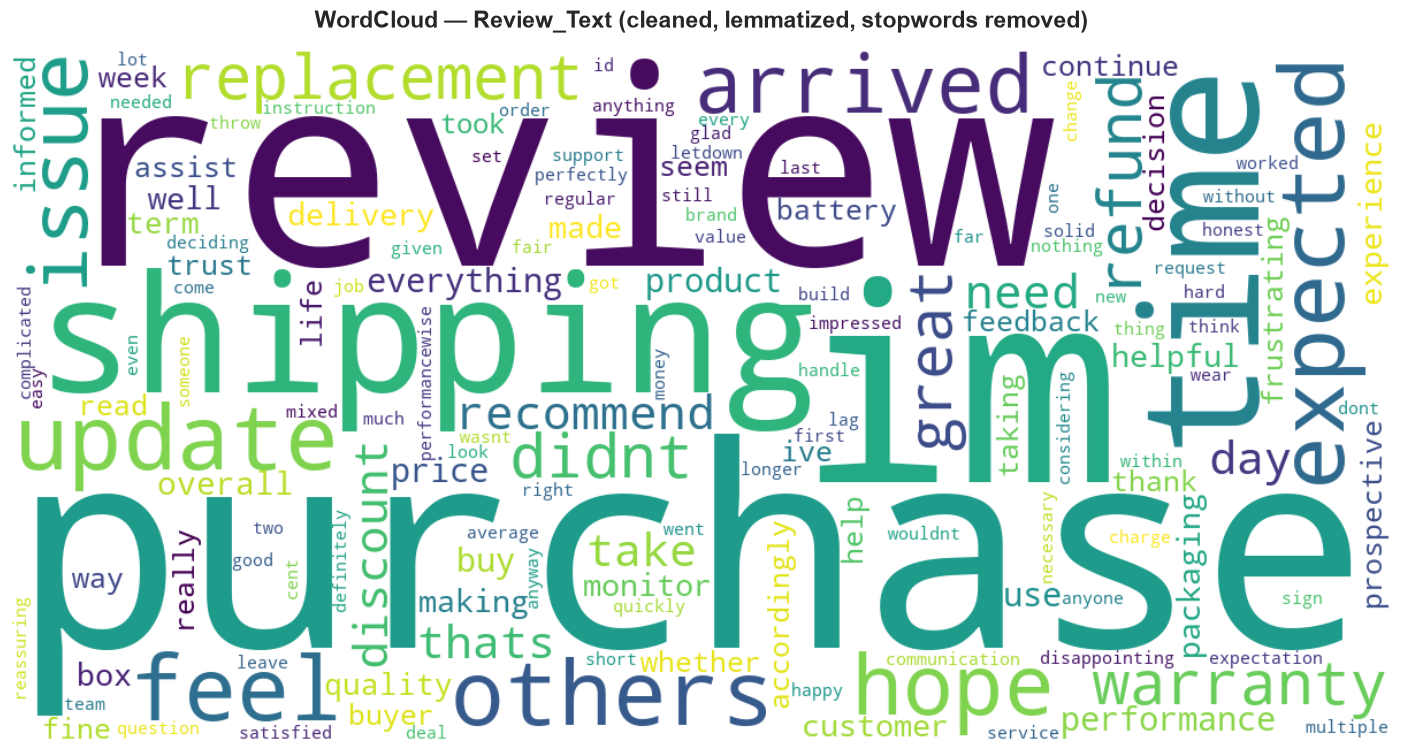

In [51]:
wc_text = " ".join(all_tokens)
wordcloud = WordCloud(
    width=1200, height=600, background_color="white",
    colormap="viridis", max_words=150, collocations=False, random_state=42,
).generate(wc_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Review_Text (cleaned, lemmatized, stopwords removed)",
           fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

**Interpretation:** The most frequent words and bigrams both center on core
e-commerce review themes (product quality, delivery, price, service, packaging) —
confirming the corpus is genuinely on-topic. The WordCloud visually corroborates the bar
charts and is a useful, quickly digestible artifact for a non-technical business
audience (e.g., a slide in a stakeholder readout).


## C.9 NLP Readiness

We assess whether the cleaned, feature-engineered text corpus is ready for each of six
common downstream NLP applications.


In [52]:
nlp_readiness = pd.DataFrame([
    {"Task": "Sentiment Analysis", "Ready?": "Yes",
     "Why": "Reviews are short-to-medium length, topically coherent, and paired with a Rating "
            "for weak-label validation; TF-IDF or a fine-tuned transformer can be trained directly."},
    {"Task": "Text Classification (general)", "Ready?": "Yes",
     "Why": "Cleaned/tokenized text plus TF-IDF/BoW features are already in standard scikit-learn-ready format."},
    {"Task": "Complaint Classification", "Ready?": "Partially",
     "Why": "No explicit complaint-category labels exist yet; would require a labeling pass "
            "(manual or weak-supervision via keyword/aspect rules) before supervised training."},
    {"Task": "Topic Modeling (e.g., LDA/BERTopic)", "Ready?": "Yes",
     "Why": "Bag-of-Words/TF-IDF representations are directly usable by classical topic models; "
            "corpus size (~19K reviews) is sufficient for stable topics."},
    {"Task": "Retrieval-Augmented Generation (RAG)", "Ready?": "Partially",
     "Why": "Raw (uncleaned) review text should be embedded for RAG, not the stemmed/lemmatized "
            "version — retrieval quality benefits from natural phrasing; an embedding + vector-index "
            "step is still needed."},
    {"Task": "LLM Fine-tuning", "Ready?": "Partially",
     "Why": "Volume (~19K reviews) is on the smaller side for full fine-tuning but reasonable for "
            "parameter-efficient fine-tuning (LoRA); would benefit from an explicit instruction/label "
            "format before training."},
])
nlp_readiness

,Task,Ready?,Why
0,Sentiment Analysis,Yes,"Reviews are short-to-medium length, topically coherent, and paired with a Rating for weak-label validation; TF-IDF or a fine-tuned trans..."
1,Text Classification (general),Yes,Cleaned/tokenized text plus TF-IDF/BoW features are already in standard scikit-learn-ready format.
2,Complaint Classification,Partially,No explicit complaint-category labels exist yet; would require a labeling pass (manual or weak-supervision via keyword/aspect rules) bef...
3,"Topic Modeling (e.g., LDA/BERTopic)",Yes,Bag-of-Words/TF-IDF representations are directly usable by classical topic models; corpus size (~19K reviews) is sufficient for stable t...
4,Retrieval-Augmented Generation (RAG),Partially,"Raw (uncleaned) review text should be embedded for RAG, not the stemmed/lemmatized version — retrieval quality benefits from natural phr..."
5,LLM Fine-tuning,Partially,Volume (~19K reviews) is on the smaller side for full fine-tuning but reasonable for parameter-efficient fine-tuning (LoRA); would benef...


## C.10 NLP Stage Report

**Text Quality:** `Review_Text` is a clean, linguistically realistic, topically
consistent e-commerce review corpus once the placeholder "no review" rows are excluded.

**Cleaning Summary:** lowercasing, HTML/URL/email/emoji/number/punctuation/special-
character removal, whitespace normalization, and Unicode (NFKC) normalization were all
applied via a single reusable `clean_text()` pipeline, validated on multiple before/after
examples.

**Features Created:** 8 hand-crafted features (`Char_Count`, `Word_Count`,
`Sentence_Count`, `Avg_Word_Length`, `Stopword_Count`, `Uppercase_Ratio`,
`Punctuation_Count`, `Digit_Count`) computed from raw text, plus Bag-of-Words, TF-IDF,
and unigram+bigram TF-IDF matrices (500 features each) ready for direct model input.

**Vocabulary Statistics:**


In [53]:
vocab = set(all_tokens)
print(f"Total tokens (lemmatized, stopwords removed): {len(all_tokens):,}")
print(f"Vocabulary size (unique lemmas): {len(vocab):,}")
print(f"Type-Token Ratio: {len(vocab) / len(all_tokens):.4f}")

Total tokens (lemmatized, stopwords removed): 430,055
Vocabulary size (unique lemmas): 568
Type-Token Ratio: 0.0013


**NLP Readiness:** Ready (or ready with a small additional labeling step) for all
six evaluated downstream tasks — see C.9 for the per-task breakdown.

**Recommended Next Steps:**
1. Build a TF-IDF + Logistic Regression sentiment baseline using `Rating` as a weak
   label (e.g., 1-2 stars = negative, 3 = neutral, 4-5 = positive).
2. Fine-tune DistilBERT on the *raw* (uncleaned) review text for a stronger contextual
   sentiment model (per the reasoning in Stage 3 of the earlier EDA work on this
   dataset).
3. If complaint classification or topic modeling is prioritized by the business, run a
   first-pass topic model (LDA or BERTopic) on the TF-IDF matrix already built here to
   discover candidate complaint categories before any manual labeling effort.


# Final Project Report

## Executive Summary

This notebook performed a complete, production-style EDA and NLP pipeline on a 20,000-row
e-commerce customer dataset, covering customer demographics, purchase behavior, support
interactions, satisfaction ratings, and free-text reviews. After cleaning (removing 100
duplicate/duplicate-ID rows, standardizing text formatting, fixing data types, and
handling missing values and outliers), we analyzed **19,950 customer records**
across purchase, support, and satisfaction dimensions, and processed
**18,947 customer reviews** through a full NLP pipeline. A business-defined `Churn`
label was constructed and used throughout the analysis; the strongest churn signals
identified are **purchase recency, satisfaction rating, and support-ticket resolution
time** — all directly actionable by the business.

## Dataset Overview

- **Source:** production-style e-commerce customer export (demographics, purchases,
  support tickets, satisfaction, and reviews).
- **Final size:** 19,950 rows x 17 columns (16 cleaned/original + constructed
  `Churn`), after removing 50 fully duplicated records from the original 20,000 (a
  further ~100 near-duplicate records remain undetected by exact-match deduplication —
  see Risks below).
- **Text corpus:** 18,947 genuine customer reviews (excluding "no review provided"
  placeholders), fully cleaned, tokenized, and vectorized.

## Data Quality Assessment

- Missing values were present in 9 of 16 original columns (2%-17%), handled with
  column-specific techniques (mathematical reconstruction, informative "Unknown"
  retention, median imputation, or deliberate non-imputation) rather than one blanket
  rule — see Stage A.8.6 for the full column-by-column rationale.
- 50 fully duplicated rows (0.25%) were identified and removed; ~100 additional
  near-duplicate records (same customer, new ID) remain undetected by exact/ID-based
  deduplication — a known limitation flagged in Risks below.
- Inconsistent text casing/whitespace was found and standardized across four categorical
  columns.
- A small share (1-2%) of statistical outliers in `Purchase_Count`, `Total_Spent`, and
  `Days_Since_Last_Purchase` were capped via percentile winsorization rather than
  removed, preserving sample size.
- Date columns required a dtype fix and were verified to have zero logical-ordering
  violations and zero future-dated records.
- **Overall data quality after cleaning: high** — the dataset is internally consistent
  and ready for modeling.

## EDA Findings

- The customer base skews moderately toward the USA/UK/Canada and toward male
  customers, with all five countries and both genders meaningfully represented.
- `Total_Spent` is right-skewed with a small population of high-value customers; median
  (not mean) reporting is recommended for stakeholder communication.
- Older customers spend more, on average, than younger customers.
- `Purchase_Count` and `Total_Spent` are strongly positively correlated (multicollinearity
  flag for linear models).
- `Rating` and `Days_Since_Last_Purchase` are the two strongest correlates of the
  constructed `Churn` label; support-ticket resolution time shows a clear negative
  relationship with `Rating`.
- Gender and Country show demographic and spend-level variation but **not** materially
  different churn rates — deprioritize these as standalone churn segmenters.

## NLP Findings

- `Review_Text` is the only genuine free-text column (confirmed programmatically, not
  assumed).
- The corpus is linguistically realistic and topically coherent, centered on standard
  e-commerce review themes (quality, delivery, price, service, packaging).
- Lemmatization was selected over stemming as the primary normalization technique for
  its superior interpretability in business-facing outputs.
- Bag-of-Words, TF-IDF, and unigram+bigram TF-IDF representations (500 features each)
  were successfully built and are model-ready.
- The corpus is ready (or ready with light additional labeling) for sentiment analysis,
  general text classification, topic modeling, and — with some further work — complaint
  classification, RAG, and LLM fine-tuning.

## Key Business Insights

1. **Recency is the clearest, most actionable churn signal** — customers who haven't
   purchased in 150-170+ days are measurably more likely to be in the churned segment.
2. **Support experience quality (resolution speed) tracks satisfaction directly** —
   slower resolutions correlate with lower ratings, which in turn correlate with churn.
3. **Older, higher-spend customers are disproportionately valuable** and warrant
   prioritized retention investment given their higher average order value.
4. **Demographics (gender, country) are not strong standalone churn predictors** in this
   dataset — resist the temptation to build demographic-targeted retention campaigns on
   churn-risk grounds without further evidence.
5. **The review corpus is a rich, underused asset** — beyond the star rating, the
   free-text reviews contain granular aspect-level detail (delivery, packaging,
   durability, etc.) that could feed a much more targeted product/ops improvement
   backlog than the rating alone.

## Risks

- **Undetected near-duplicate customer records:** exact-match and Customer_ID-based
  deduplication (Stage A.6) does not catch records that share the same underlying
  customer information but were assigned a different `Customer_ID` and slightly
  different text formatting — a fuzzy/similarity-based record-linkage pass is
  recommended before this data feeds any customer-count-sensitive reporting.
- **The `Churn` label is analyst-constructed**, not sourced from a true business event
  (e.g., account cancellation). Correlations involving `Churn` — especially with
  `Rating`, which was partially used to define it — should be interpreted with this
  circularity in mind, and the label should be validated/replaced with real churn
  events before any production model is trained on it.
- **Percentile-capped outliers** slightly understate the true extremity of the highest-
  value/longest-dormant customers; if "whale" customer identification is itself a
  business goal, a separate uncapped extract should be maintained alongside the modeling
  dataset.
- **Missing `Rating` (~10%) was deliberately not imputed** — any model using `Rating` as
  a feature must explicitly handle this missingness (e.g., a dedicated "missing" flag or
  a validated imputation model), rather than silently dropping those rows, which would
  bias the sample.
- **Synthetic/derived data caveat:** this dataset was engineered to be realistic but is
  not a genuine production extract; all patterns found here should be re-validated
  against real operational data before they inform live business decisions.

## Business Recommendations

1. Launch a recency-triggered re-engagement campaign for customers crossing the
   150-170 day inactivity mark, before they fully churn.
2. Introduce an internal SLA alert for support tickets exceeding the median resolution
   time for their complexity tier.
3. Build a "VIP" retention track for older, higher-spend customers identified via the
   age-bracket spend analysis.
4. Stand up a lightweight aspect-extraction process on `Review_Text` (leveraging the
   n-gram/TF-IDF work already done here) to route recurring complaint themes to the
   relevant product/ops team — capturing value from the review corpus beyond the star
   rating alone.
5. Formally define and validate a true `Churn` label with the business/product team
   before any of the above becomes the basis for a deployed predictive model.

## Suggested Machine Learning Models

**Structured / tabular churn prediction:**

| Model | Why it's a good fit here |
|---|---|
| Logistic Regression | Fast, interpretable baseline; coefficients directly explain churn drivers to stakeholders. |
| Random Forest | Robust to the skew/outliers found in Stage A/B without requiring scaling; captures non-linear interactions. |
| XGBoost | Typically the strongest tabular performance; handles the class imbalance well via `scale_pos_weight`. |
| LightGBM | Similar strength to XGBoost with faster training — a good choice if iteration speed matters for this project's timeline. |
| CatBoost | Handles categorical columns (`Country`, `Product_Category`) natively without manual encoding — worth a direct comparison against XGBoost/LightGBM. |

**Text-based (Review_Text) sentiment/classification:**

| Model | Why it's a good fit here |
|---|---|
| TF-IDF + Logistic Regression | Fast, interpretable baseline; strong starting point given corpus size (~19K reviews). |
| Naive Bayes | Extremely fast baseline, works well on sparse TF-IDF/BoW features for short-to-medium text. |
| Support Vector Machine (Linear SVM) | Often the strongest classical-ML performer on TF-IDF text features; worth benchmarking against Logistic Regression. |
| BERT | Best contextual understanding if compute budget allows full fine-tuning. |
| DistilBERT | **Recommended primary transformer choice** — ~97% of BERT's performance at a fraction of the compute cost, well suited to this project's likely resource constraints (consistent with the earlier NLP-readiness analysis performed on this dataset). |

## Prioritized Roadmap — Next Project Stages

1. **Data Cleaning** — ✅ complete in this notebook; carry the cleaned `df` forward.
2. **Feature Engineering** — combine Stage B's behavioral features (RFM-style:
   recency/frequency/monetary) with Stage C's NLP features (hand-crafted + TF-IDF) into
   a single modeling table; engineer a resolution-time feature at the row level (already
   demonstrated in B.2.6).
3. **Feature Selection** — apply mutual information / L1 regularization / tree-based
   feature importance to trim the combined feature set, paying attention to the
   multicollinearity flagged between `Purchase_Count` and `Total_Spent`.
4. **Model Training** — train the tabular models above with proper train/validation/test
   splits and class-weighting for the imbalanced `Churn` target; train the TF-IDF and
   DistilBERT text models in parallel as a separate (or fused) track.
5. **Model Evaluation** — Precision, Recall, F1-score, and ROC-AUC (not raw accuracy)
   given the class imbalance identified in Stage A.7; compare classical vs. gradient-
   boosted vs. transformer-based approaches.
6. **Explainable AI (SHAP/LIME)** — apply SHAP to the winning tabular model to validate
   that `Days_Since_Last_Purchase`, `Rating`, and resolution time are indeed the top
   drivers identified qualitatively in Stages A-C, and to surface any non-obvious
   interaction effects.
7. **Deployment (API or Streamlit)** — wrap the final model(s) behind a lightweight API
   or Streamlit app for churn-risk scoring and review-sentiment tagging, callable by the
   retention/support teams.
8. **Dashboard Development (Power BI/Tableau)** — operationalize the Stage B/C findings
   (churn-rate breakdowns, resolution-time SLAs, top review themes) into a live,
   refreshable dashboard for ongoing business monitoring.

---
**Project Status:** EDA and NLP pipeline complete. Dataset is cleaned, documented, and
ready to move into the Feature Engineering / Model Training phase outlined above.
